In [123]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Dense,LSTM, Dropout,Input, Concatenate
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import TimeSeriesSplit
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime, timedelta



## Para el siguiente analisis y posteriores prediccions, se utilizaran 2 Datasets. 

**1. "Longitud_Lineas.csv" . Este dataset es el creado en el notebook anterior donde se calcula la longitud total en KM de cada linea de Subterraneo**

**2 . "estaciones_accesibles.csv" . Este dataframe contiene la cantidad de Ascensores y Escaleras Mecanicas que hay en cada Estacion de cada una de las lineas de Subte**

- 1. Carga del primer dataset.

- Este DataFrame contiene información sobre las Lineas de subte de la Ciudad de Buenos Aires detallando la la Longitud en Km de cada una.

In [220]:
#Cargo el Dataset 'Longitud_Lineas.csv', ordeno los datos de acuerdo a la columna 'lineasub' y muestro las primeras 10 filas.
longitudLineas=pd.read_csv("Longitud_Lineas.csv")
longitudLineas= longitudLineas.sort_values(by='lineasub')
print("Longitud de las Lineas de Subte de Buenos Aires ")
longitudLineas.head(10)


Longitud de las Lineas de Subte de Buenos Aires 


,lineasub,longitud,longitud_km
0,LINEA A,0.1032,11.4874
1,LINEA B,0.1249,13.9062
2,LINEA C,0.0411,4.5778
3,LINEA D,0.1071,11.9272
4,LINEA E,0.1228,13.6654
5,LINEA H,0.0754,8.3958


In [221]:
longitudLineas.columns

Index(['lineasub', 'longitud', 'longitud_km'], dtype='object')

In [223]:
#RENOMBRO LA COLUMNA lineasub x linea para que coincida con el nombre de la columna del otro DataFrame a analizar 'estaciones-accesibles.csv 
longitudLineas = longitudLineas.rename(columns={'lineasub': 'linea'})

In [224]:
#ELIMINO la palabra LINEA de la columna linea PARA QUE QUEDE SOLO LA LETRA DE LA LINEA.
longitudLineas['linea'] = longitudLineas['linea'].str.replace('LINEA ', '')

- 2. Carga del segundo dataset.

- Este DataFrame contiene información sobre las ESTACIONES de subte de la Ciudad de Buenos Aires detallando la cantidads de ASCENSORES y ESCALERAS MECANICAS que posee cada una.

In [225]:
#Cargo el Dataset "estaciones_accesibles.csv", ordenando los datos de acuerdo a la columna 'linea' y muestro las primeras 10 filas.
dfea=pd.read_csv("estaciones-accesibles.csv")

In [226]:

dfea= dfea.sort_values(by='linea')
dfea.head(10)


,long,lat,linea,estacion,escaleras_mecanicas,ascensores
0,-58.4364,-34.6183,A,ACOYTE,2,2
14,-58.4696,-34.6307,A,SAN PEDRITO,3,2
13,-58.4635,-34.6291,A,SAN JOSE DE FLORES,4,3
12,-58.3868,-34.6094,A,SAENZ PEÑA,2,0
10,-58.4412,-34.6204,A,PRIMERA JUNTA,3,2
9,-58.4067,-34.6098,A,PLAZA MISERERE,6,0
8,-58.3710,-34.6088,A,PLAZA DE MAYO,0,1
11,-58.4486,-34.6235,A,PUAN,3,3
6,-58.3743,-34.6086,A,PERU,2,2
5,-58.4152,-34.6108,A,LORIA,1,1


- COMBINACION DE LOS KM QUE LE CORRESPONDE A CADA LINEA.

In [227]:
df = dfea

In [228]:
#AGREGO UNA NUEVA FEATURE O COLUMNA CON EL NOMBRE "lomgitud_km", EL CUAL VA A TENER LA LONGTUD DE CADA LINEA DE SUBTERRANEO.
df['longitud_km'] = df['linea'].map(longitudLineas.set_index('linea')['longitud_km'])

In [229]:
#VISUALIZO LA NUEVA COLUMNA LONGITUD_KM
df.head(10)

,long,lat,linea,estacion,escaleras_mecanicas,ascensores,longitud_km
0,-58.4364,-34.6183,A,ACOYTE,2,2,11.4874
14,-58.4696,-34.6307,A,SAN PEDRITO,3,2,11.4874
13,-58.4635,-34.6291,A,SAN JOSE DE FLORES,4,3,11.4874
12,-58.3868,-34.6094,A,SAENZ PEÑA,2,0,11.4874
10,-58.4412,-34.6204,A,PRIMERA JUNTA,3,2,11.4874
9,-58.4067,-34.6098,A,PLAZA MISERERE,6,0,11.4874
8,-58.3710,-34.6088,A,PLAZA DE MAYO,0,1,11.4874
11,-58.4486,-34.6235,A,PUAN,3,3,11.4874
6,-58.3743,-34.6086,A,PERU,2,2,11.4874
5,-58.4152,-34.6108,A,LORIA,1,1,11.4874


In [230]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 93 entries, 0 to 92
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   long                 93 non-null     float64
 1   lat                  93 non-null     float64
 2   linea                93 non-null     object 
 3   estacion             93 non-null     object 
 4   escaleras_mecanicas  93 non-null     int64  
 5   ascensores           93 non-null     int64  
 6   longitud_km          93 non-null     float64
dtypes: float64(3), int64(2), object(2)
memory usage: 5.8+ KB


In [231]:
df.isnull().sum()

long                   0
lat                    0
linea                  0
estacion               0
escaleras_mecanicas    0
ascensores             0
longitud_km            0
dtype: int64

In [232]:
print(df.isna().sum().sum())

0


In [233]:
df.duplicated().sum()

0

In [234]:
df.dtypes



long                   float64
lat                    float64
linea                   object
estacion                object
escaleras_mecanicas      int64
ascensores               int64
longitud_km            float64
dtype: object

In [235]:
df.columns


Index(['long', 'lat', 'linea', 'estacion', 'escaleras_mecanicas', 'ascensores', 'longitud_km'], dtype='object')

In [236]:
df.sample(5)



,long,lat,linea,estacion,escaleras_mecanicas,ascensores,longitud_km
47,-58.4113,-34.5882,D,BULNES,1,0,11.9272
54,-58.4521,-34.5662,D,JOSE HERNANDEZ,5,0,11.9272
16,-58.3923,-34.6044,B,CALLAO,5,3,13.9062
45,-58.3806,-34.6042,D,9 DE JULIO,2,0,11.9272
0,-58.4364,-34.6183,A,ACOYTE,2,2,11.4874


df.shape



In [237]:
df.describe()


,long,lat,escaleras_mecanicas,ascensores,longitud_km
count,93.0000,93.0000,93.0000,93.0000,93.0000
mean,-58.4079,-34.6059,3.5054,1.2473,11.2907
std,0.0305,0.0180,2.4075,1.6462,3.0232
min,-58.4864,-34.6413,0.0000,0.0000,4.5778
25%,-58.4268,-34.6183,2.0000,0.0000,11.4874
50%,-58.4024,-34.6046,3.0000,0.0000,11.9272
75%,-58.3807,-34.5945,5.0000,3.0000,13.6654
max,-58.3699,-34.5556,11.0000,7.0000,13.9062


**ANALISIS CON HORAS DIARIAS APROXIMADAS DE OPERACION DE CADA LINEA**

- DATOS OBTENIDOS DEL ARCHIVO "ANALISIS_PREDICCIONES_historico_2014.ipynb"

In [238]:
#DETERMINO LAS HORAS DIARIAS DE FUNCIONAMIENTO DE CADA LINEA DE SUBTE. ESTE DATO SURJE DEL ARCHIVO "ANALISIS_historico_2014.ipynb"
#A: 19 horas
#B: 23 horas
#C: 22 horas
#D: 22 horas
#E: 23 horas
#H: 23 horas
horas_diarias = {'A':19, 'B':23, 'C':22, 'D':22 , 'E':23 ,'H':23} 
#AGREGO UNA NUEVA FEATURE O COLUMNA CON EL NOMBRE "horas_diarias", EL CUAL VA A TENER LA CANTIDAD DE HORAS DIARIAS DE FUNCIONAMIENTO DE CADA LINEA DE SUBTE.
df['horas_diarias'] = df['linea'].map(horas_diarias)

In [239]:
#VISUALIZACION DE CARACTERISTICAS DE CADA LINEA.
pd.set_option('display.width',1000)
pd.set_option('display.max_columns',None)
df_detalle = df.groupby('linea')[['ascensores', 'escaleras_mecanicas']].sum().reset_index()

print("Detalle de las Lineas de Subte de Buenos Aires")
df_detalle['longitud_km']= df.groupby('linea')['longitud_km'].mean().values
print(df_detalle)

Detalle de las Lineas de Subte de Buenos Aires
  linea  ascensores  escaleras_mecanicas  longitud_km
0     A          22                   34      11.4874
1     B          22                   69      13.9062
2     C           4                   28       4.5778
3     D          11                   60      11.9272
4     E          12                   68      13.6654
5     H          45                   67       8.3958


In [240]:
#Creo un nuevo dataframe "dfkwh" para utilizarlo para el calculo de consumo energetico.
dfkwh = df_detalle

In [241]:
dfkwh

,linea,ascensores,escaleras_mecanicas,longitud_km
0,A,22,34,11.4874
1,B,22,69,13.9062
2,C,4,28,4.5778
3,D,11,60,11.9272
4,E,12,68,13.6654
5,H,45,67,8.3958


- Agrego una nueva columna "horas_diarias" al dataframe "dfkwh" y le asigno las correspondientes horas de operacion a cada linea.

In [242]:
#Horas Diarias de Funcionamiento de cada Linea de Subte.
horas_diarias = {'A':19, 'B':23, 'C':22, 'D':22 , 'E':23 ,'H':23} 
#AGREGO UNA NUEVA FEATURE O COLUMNA CON EL NOMBRE "horas_diarias".
dfkwh['horas_diarias'] = dfkwh['linea'].map(horas_diarias)

In [243]:
#Visualizo el nuevo dataframe "dfkwh"
dfkwh

,linea,ascensores,escaleras_mecanicas,longitud_km,horas_diarias
0,A,22,34,11.4874,19
1,B,22,69,13.9062,23
2,C,4,28,4.5778,22
3,D,11,60,11.9272,22
4,E,12,68,13.6654,23
5,H,45,67,8.3958,23


## ANALISIS de CONSUMO DE ENERGIA "estimado" de los ASCENSORES y ESCALERAS MECANICAS en KWH. 

**ALGUNOS PUNTOS A TENER EN CUENTA**

**¿ Cuánto consume un Ascensor ?**
- Hay que tener en cuenta algunos de los principales factores que afectan a la potencia requerida y que son; la capacidad y las dimensiones, en el caso de ascensores convencionales ambos factores están relacionados, por ejemplo, si hablamos de ascensores para cuatro personas, tenemos que la capacidad de carga máxima será de 300 Kg., (Se calcula 75 Kg., por personas) y unas dimensiones que están calculadas por normativa. Aunque de menor importancia, también existen otros factores como velocidad, altura a elevar, peso de la cabina, etc, que afectaran en mayor o menor medida al consumo del ascensor.

- Además de este punto, la instalación de uno u otro tipo o sistema utilizado tiene mucha importancia en el consumo pudiendo haber diferencias significativas entre ellos, en la actualidad podemos encontrar principalmente tres tipos, los ascensores electromecánicos o eléctricos, los ascensores hidráulicos y los ascensores gearless o de última generación.

- Por ejemplo, el consumo eléctrico para un ascensor hidráulico de 4 personas sería de entre unos 7,5 kWh a unos 10 kWh., en este punto tenemos que tener en cuanta dos puntos importantes, el primero es que el ascensor hidráulico solo consume energía cuando sube, ya que cuando baja utiliza el propio peso de la cabina sin intervenir la central hidráulica, otro punto importante es que los sistemas hidráulicos más antiguos pueden llegar a necesitar hasta un 40 % más de energía para el mismo rendimiento, algo a tener también muy en cuenta.

- En cuanto a ascensores electromecánicos, tenemos consumos que pueden variar entre unos 3 kWh y unos 4 kWh., en función de si se trata de un sistema con variador de frecuencia o de dos velocidades principalmente.

- En cuanto a los sistemas de última generación, los cuales no utilizan reductores, lo que les hace mucho más efectivos, tenemos que el consumo puede variar entre unos 2 kWh y 2,5 kWh, principalmente.

**¿Cuánto consume un ascensor para 6 personas**
- En el caso de tratarse un ascensor con capacidad para 6 personas, el consumo aumentaría ligeramente, tendríamos en los sistemas hidráulicos entre 9,5 kWh y 13 kWh, principalmente, mientras que en los sistema electromecánicos estaríamos hablando de entre unos 4,5 kWh y unos 5,5 kWh y en los motores de última generación entre 3 kWh y 4,5 kWh principalmente.

FUENTE : 
**https://ascensoresymas.com/cuanto-consume-un-ascensor-segun-personas-y-dimensiones/**

**¿ Cuánto consume una Escalera Mecanica ?**
-S egún datos de OTIS, el consumo de un ascensor eléctrico convencional para diez personas como en el que se puede subir uno en unos grandes almacenes aumenta a unos 6.700 kWh/año. Esta diferencia es aún mayor en el caso de las escaleras mecánicas, cuyo gasto energético puede variar de unos 7.000 kWh/año a cerca de 31.000.

-31000 / 12 / 30 / 22 = 3,9 kwh

**FUENTE : https://blogs.elpais.com/eco-lab/2010/09/escaleras-mecanicas-o-ascensor.html**

In [244]:
#VISUALIZACION DE CARACTERISTICAS DE CADA LINEA.
pd.set_option('display.width',1000)
pd.set_option('display.max_columns',None)
df_detalle = dfkwh.groupby('linea')[['ascensores', 'escaleras_mecanicas']].sum().reset_index()

#df_detalle['longitud_km']= df.groupby('linea')['longitud_km'].mean().values
print(df_detalle)

  linea  ascensores  escaleras_mecanicas
0     A          22                   34
1     B          22                   69
2     C           4                   28
3     D          11                   60
4     E          12                   68
5     H          45                   67


**En este punto, comenzamos a calcular los CONSUMOS ESTIMADOS.**

## Variables de Configuración

El análisis utiliza dos variables clave para estimar el consumo energético:
- `consumoasckwh = 3.5 kWh`: Representa el consumo aproximado por hora de los ascensores
- `consumoesckwh = 1.1 kWh`: Representa el consumo aproximado por hora de las escaleras mecánicas

## Cálculo de Horas de Operación

Se han establecido las horas diarias de funcionamiento para cada línea de transporte:
- Línea A: 19 horas
- Línea B: 23 horas
- Línea C: 22 horas
- Línea D: 22 horas
- Línea E: 23 horas
- Línea H: 23 horas

Horas diarias de funcionamiento de todas las lineas: Hs. 132


## Cálculo de Consumo Energético Diario

1. **Consumo de Ascensores**:
   - Fórmula: `consumo_ascensor = consumoasckwh * horasdiarias`
   - Resultado: `3.5 kWh * 132 = 462 kWh`
   - Salida: `Consumo diario (Ascensores): KWh 462.0`

2. **Consumo de Escaleras Mecánicas:**
   - Fórmula: `consumo_escalera = consumoesckwh * horasdiarias`
   - Resultado: `1.1 kWh * 132 = 145.2 kWh`
   - Salida: `Consumo diario (Escaleras Mecanicas): KWh 145.2`

## Aplicación

Este análisis proporciona una estimación base del consumo energético diario de los medios de accesibilidad en la red de subterraneos.
Los resultados permiten:
- Realizar proyecciones de costos operativos
- Evaluar oportunidades de eficiencia energética
- Planificar mantenimientos preventivos
- Comparar con consumos reales para detectar anomalías

Los valores aproximados utilizados (3.5 kWh para ascensores y 1.1 kWh para escaleras) pueden ajustarse según datos específicos de fabricante o mediciones reales para mayor precisión en el análisis.

In [245]:
# Variables para ajustar el consumo de kwh para analisis de consumos.

# Consumo de kwh por hora de funcionamiento de ascensores y escaleras mecanicas.

consumoasckwh = 3.5  # kwh (Valor Aproximado)
consumoesckwh = 1.1  # kwh (Valor Aproximado)

# AGREGO 2 NUEVAS COLUMNAS al Dataframe "dfkwh", y calculo de consumo de kwh por hora segun el funcionamiento de ascensores y escaleras mecanicas.
dfkwh['consumo_asc_kwh'] = consumoasckwh * dfkwh['ascensores'] * dfkwh['horas_diarias']
dfkwh['consumo_esc_kwh'] = consumoesckwh * dfkwh['escaleras_mecanicas'] * dfkwh['horas_diarias']

dfkwh['consumo_total'] = dfkwh['consumo_asc_kwh'] + dfkwh['consumo_esc_kwh']


#df_consumo_total = dfkwh.groupby('linea')['consumo_total'].sum().reset_index()

#REDONDEO LOS VALORES DECIMALES DE LAS COLUMNAS.
dfkwh['consumo_total'] = dfkwh['consumo_total'].round(1)
dfkwh['consumo_esc_kwh'] = dfkwh['consumo_esc_kwh'].round(1)
dfkwh['longitud_km'] = dfkwh['longitud_km'].round(1)



In [246]:
# Visualizo el datataframe "dfkwh" con el TOTAL de KWH de consumo energetico POR LINEA DE SUBTE.
dfkwh

,linea,ascensores,escaleras_mecanicas,longitud_km,horas_diarias,consumo_asc_kwh,consumo_esc_kwh,consumo_total
0,A,22,34,11.5,19,1463.0,710.6,2173.6
1,B,22,69,13.9,23,1771.0,1745.7,3516.7
2,C,4,28,4.6,22,308.0,677.6,985.6
3,D,11,60,11.9,22,847.0,1452.0,2299.0
4,E,12,68,13.7,23,966.0,1720.4,2686.4
5,H,45,67,8.4,23,3622.5,1695.1,5317.6


En el siguiente codigo, se agregaron dos nuevas columnas al DataFrame "df" para estimar el consumo diario de energía (en kWh) asociado al funcionamiento de ascensores y escaleras mecánicas por estación:
1. •	consumo_ascensores_kwh: Se calcula multiplicando la cantidad de ascensores por un consumo estimado de 3.5 kWh por hora y por la cantidad de horas diarias de funcionamiento (horas_diarias).
2. •	consumo_escaleras_mecanicas_kwh: Se obtiene multiplicando la cantidad de escaleras mecánicas por un consumo estimado de 1.1 kWh por hora y por horas_diarias.

Estas estimaciones permiten evaluar el consumo energético total diario por estación, considerando la infraestructura operativa instalada.

In [247]:
#AGREGO 2 NUEVAS COLUMNAS al Dataframe "df", y calculo de consumo de kwh por hora segun la cantidad de ascensores y escaleras mecanicas que hay por estacion.

df['consumo_ascensores_kwh'] = df.apply(lambda row: row['ascensores'] * 3.5 * row['horas_diarias'], axis=1)
df['consumo_escaleras_mecanicas_kwh'] = df.apply(lambda row: row['escaleras_mecanicas'] * 1.1 * row['horas_diarias'], axis=1)

In [252]:
df.sample(5)

,long,lat,linea,estacion,escaleras_mecanicas,ascensores,longitud_km,horas_diarias,consumo_ascensores_kwh,consumo_escaleras_mecanicas_kwh
58,-58.4212,-34.5814,D,PLAZA ITALIA,5,0,11.9272,22,0.0,121.0
92,-58.4047,-34.6152,H,VENEZUELA,4,3,8.3958,23,241.5,101.2
55,-58.4565,-34.5623,D,JURAMENTO,6,3,11.9272,22,231.0,145.2
89,-58.4060,-34.6089,H,ONCE,10,3,8.3958,23,241.5,253.0
67,-58.3704,-34.6033,E,CORREO CENTRAL,9,4,13.6654,23,322.0,227.7


- Visualizo las columnas de los 3 Dataframes creados para su posterior analisis.

In [251]:
dfkwh.columns

Index(['linea', 'ascensores', 'escaleras_mecanicas', 'longitud_km', 'horas_diarias', 'consumo_asc_kwh', 'consumo_esc_kwh', 'consumo_total'], dtype='object')

In [249]:
df_detalle.columns

Index(['linea', 'ascensores', 'escaleras_mecanicas'], dtype='object')

In [250]:
df.columns

Index(['long', 'lat', 'linea', 'estacion', 'escaleras_mecanicas', 'ascensores', 'longitud_km', 'horas_diarias', 'consumo_ascensores_kwh', 'consumo_escaleras_mecanicas_kwh'], dtype='object')

In [253]:
#REDONDEO los valores DECIMALES de las columnas de consumo de kwh por hora segun la cantidad de ascensores y escaleras mecanicas que hay por estacion.
df['consumo_escaleras_mecanicas_kwh'] = df['consumo_escaleras_mecanicas_kwh'].round(1)

In [254]:
df.sample(5)

,long,lat,linea,estacion,escaleras_mecanicas,ascensores,longitud_km,horas_diarias,consumo_ascensores_kwh,consumo_escaleras_mecanicas_kwh
52,-58.4624,-34.5556,D,CONGRESO DE TUCUMAN,6,2,11.9272,22,154.0,145.2
6,-58.3743,-34.6086,A,PERU,2,2,11.4874,19,133.0,41.8
26,-58.4742,-34.5812,B,LOS INCAS,4,2,13.9062,23,161.0,101.2
43,-58.3799,-34.6219,C,SAN JUAN,2,0,4.5778,22,0.0,48.4
22,-58.4550,-34.5872,B,FEDERICO LACROZE,3,0,13.9062,23,0.0,75.9


En el siguiente codigo, se agrupan los datos por la columna linea para obtener, por cada línea de subterráneo, el total de ascensores, escaleras mecánicas, y sus respectivos consumos diarios estimados en kWh. 
- Esto permite analizar y comparar la infraestructura y el impacto energético entre líneas.

In [255]:
#CUADRO DE CONSUMOS POR LINEA DE SUBTE.
pd.set_option('display.width',1000)
pd.set_option('display.max_columns',None)
df_detalle = dfkwh.groupby('linea')[['ascensores', 'escaleras_mecanicas','consumo_asc_kwh','consumo_esc_kwh']].sum().reset_index()
print("Detalle de Cantidad de Ascensores y Escaleras Mecanicas  y Consumo por Linea de Subte")
print(df_detalle)

Detalle de Cantidad de Ascensores y Escaleras Mecanicas  y Consumo por Linea de Subte
  linea  ascensores  escaleras_mecanicas  consumo_asc_kwh  consumo_esc_kwh
0     A          22                   34           1463.0            710.6
1     B          22                   69           1771.0           1745.7
2     C           4                   28            308.0            677.6
3     D          11                   60            847.0           1452.0
4     E          12                   68            966.0           1720.4
5     H          45                   67           3622.5           1695.1


In [256]:
df2 = df[['linea', 'estacion','ascensores', 'escaleras_mecanicas']]
df2.head(6)

,linea,estacion,ascensores,escaleras_mecanicas
0,A,ACOYTE,2,2
14,A,SAN PEDRITO,2,3
13,A,SAN JOSE DE FLORES,3,4
12,A,SAENZ PEÑA,0,2
10,A,PRIMERA JUNTA,2,3
9,A,PLAZA MISERERE,0,6


**ANALISIS DE LOS DATOS**

-Generacion de Tablas de Rankings

El siguiente bloque de código genera dos rankings que permiten identificar las estaciones con mayor equipamiento en términos de accesibilidad y sus correspondientes consumos de energia:

Se ordena el DataFrame "df" de forma descendente según la cantidad de ascensores y escaleras mecánicas, generando un ranking con mayor equipamiento en cada categoría. 
- Esto facilita la priorización en análisis de consumo energético, accesibilidad o mantenimiento.

In [257]:
#Ingresar el numero de ranking que se desea obtener.

ranking = 10


#Ranking de Estaciones por mayor cantidad de Ascensores
dftotal = df.sort_values(by='ascensores', ascending=False)
print(f'Ranking TOP {ranking} de Estaciones con MAYOR cantidad de Ascensores')
print(dftotal.head(ranking).to_string(justify='all'))

print()

#Ranking de Estaciones por mayor cantidad de Escaleras Mecanicas
dftotal = df.sort_values(by='escaleras_mecanicas', ascending=False)
print(f'Ranking TOP {ranking} de Estaciones con MAYOR cantidad de Escaleras Mecanicas')
print(dftotal.head(ranking).to_string(justify='all'))

Ranking TOP 10 de Estaciones con MAYOR cantidad de Ascensores
       long      lat linea              estacion  escaleras_mecanicas  ascensores  longitud_km  horas_diarias  consumo_ascensores_kwh  consumo_escaleras_mecanicas_kwh
91 -58.4024 -34.5945  H                 SANTA FE   9                   7            8.3958      23             563.5                   227.7                          
83 -58.4055 -34.6045  H               CORRIENTES  10                   6            8.3958      23             483.0                   253.0                          
24 -58.4864 -34.5743  B     JUAN MANUEL DE ROSAS  11                   6           13.9062      23             483.0                   278.3                          
35 -58.3814 -34.6276  C             CONSTITUCION   2                   4            4.5778      22             308.0                    48.4                          
86 -58.4023 -34.6231  H              HUMBERTO 1°   5                   4            8.3958      23     

El siguiente bloque de código genera un resumen consolidado de infraestructura y consumo energético por línea de subte, incluyendo un total general:

- El informe presenta la suma total de ascensores, escaleras mecánicas y el consumo estimado de energía (en kWh) por línea de subte. 
- Se renombraron las columnas para facilitar la lectura y se añadió una fila final con el total general, brindando una visión clara y comparativa del equipamiento y consumo por línea.

In [258]:
#Suma de Ascensores, Escaleras y Consumos por Linea. 
energia=dfkwh.groupby('linea')[['ascensores','consumo_asc_kwh','escaleras_mecanicas','consumo_esc_kwh']].sum().reset_index()
#Coloca titulos y Columnas con Total General de Ascensores, Escaleras y Consumos por Linea.
energia = energia.rename(columns={'ascensores': 'Total Ascensores', 'escaleras_mecanicas' : 'Total Escaleras Mecanicas','consumo_asc_kwh':'Consumo Ascensores (KWh)', 'consumo_esc_kwh': 'Consumo Escaleras Mecanicas (KWh)' })
#Ordena por Linea
energia = energia.sort_values(by='linea')

totales = energia.sum()
energia.loc['Total'] = totales


print('TOTAL por LINEA (Ascensores, Escaleras Mecanicas y consumo en Kwh.)')
print('')
print(energia.to_string(justify='all'))

TOTAL por LINEA (Ascensores, Escaleras Mecanicas y consumo en Kwh.)

        linea  Total Ascensores  Consumo Ascensores (KWh)  Total Escaleras Mecanicas  Consumo Escaleras Mecanicas (KWh)
0           A   22               1463.0                     34                         710.6                           
1           B   22               1771.0                     69                        1745.7                           
2           C    4                308.0                     28                         677.6                           
3           D   11                847.0                     60                        1452.0                           
4           E   12                966.0                     68                        1720.4                           
5           H   45               3622.5                     67                        1695.1                           
Total  ABCDEH  116               8977.5                    326                        8001.

In [259]:
#Comprobacion de Totales
print(energia.loc['Total','Total Ascensores'])
print(energia.loc['Total','Total Escaleras Mecanicas'])
print(energia.loc['Total','Consumo Ascensores (KWh)'])
print(energia.loc['Total','Consumo Escaleras Mecanicas (KWh)'])

116
326
8977.5
8001.4


Este fragmento de código genera un resumen del consumo energético total diario de ascensores y escaleras mecánicas por línea de subte, detallando también el total combinado por línea:

- Este informe consolida el consumo energético diario estimado (en KWh) por línea, separando el aporte de ascensores y escaleras mecánicas. 
- La columna Total_General_KWh permite comparar de forma directa el impacto energético total por línea, facilitando el análisis de eficiencia y planificación energética.

In [260]:
#TOTAL CONSUMO APERTURADO DE KWH DE ASCENSORES Y ESCALERA MECANICAS.
energia2 = dfkwh.groupby('linea')[['consumo_asc_kwh','consumo_esc_kwh']].sum().reset_index()
# SUMA TOTAL DE KWH 
energia2['Total_General_KWh'] = energia2['consumo_asc_kwh'] + energia2['consumo_esc_kwh']

print('Total de Consumo de Kwh por Linea')
print(energia2)

Total de Consumo de Kwh por Linea
  linea  consumo_asc_kwh  consumo_esc_kwh  Total_General_KWh
0     A           1463.0            710.6             2173.6
1     B           1771.0           1745.7             3516.7
2     C            308.0            677.6              985.6
3     D            847.0           1452.0             2299.0
4     E            966.0           1720.4             2686.4
5     H           3622.5           1695.1             5317.6


**Visualizaciones Graficas para analisis.**

Con el siguiente código genero un gráfico de barras apiladas para visualizar la cantidad total de ascensores y escaleras mecánicas por línea de subte, incluyendo los porcentajes relativos de cada componente.

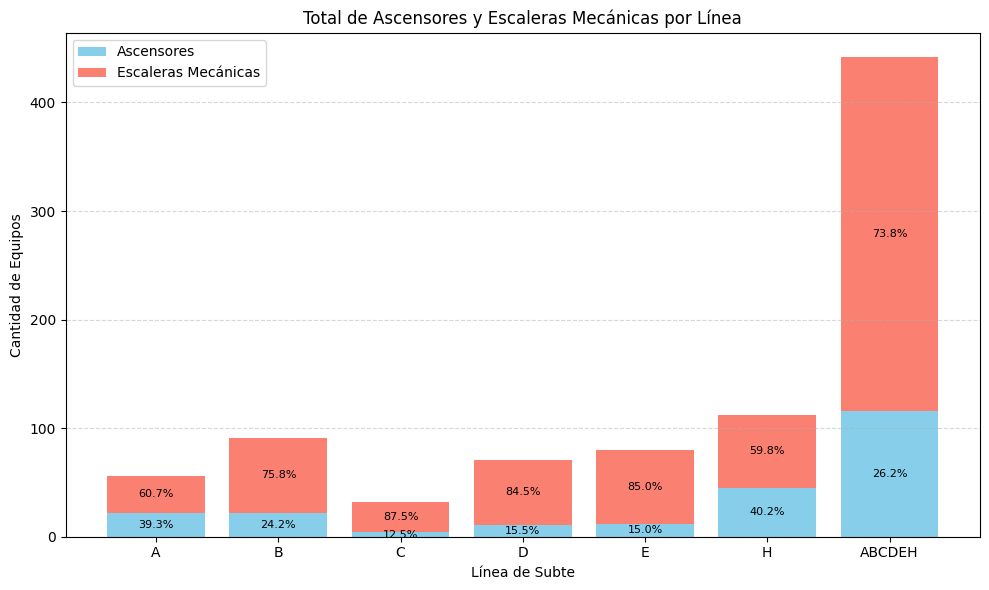

In [261]:
# Gráfico de barras apiladas: Total de Ascensores y Escaleras Mecánicas por Línea
plt.figure(figsize=(10,6))

# Barras: Ascensores (base)
plt.bar(energia['linea'], energia['Total Ascensores'], color='skyblue', label='Ascensores')

# Barras: Escaleras (apiladas sobre ascensores)
plt.bar(energia['linea'], energia['Total Escaleras Mecanicas'], 
        color='salmon', label='Escaleras Mecánicas', 
        bottom=energia['Total Ascensores'])

# Agregado de porcentajes sobre las barras
for i, row in energia.iterrows():
    total = row['Total Ascensores'] + row['Total Escaleras Mecanicas']
    if total > 0:
        # Porcentaje de ascensores (centro de la barra inferior)
        plt.text(row['linea'], row['Total Ascensores'] / 2, 
                 f"{row['Total Ascensores'] / total * 100:.1f}%", 
                 ha='center', va='center', fontsize=8, color='black')
        # Porcentaje de escaleras (centro de la barra superior)
        plt.text(row['linea'], row['Total Ascensores'] + row['Total Escaleras Mecanicas'] / 2, 
                 f"{row['Total Escaleras Mecanicas'] / total * 100:.1f}%", 
                 ha='center', va='center', fontsize=8, color='black')

# Configuración del gráfico
plt.title('Total de Ascensores y Escaleras Mecánicas por Línea')
plt.xlabel('Línea de Subte')
plt.ylabel('Cantidad de Equipos')
plt.legend()
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Mostrar gráfico
plt.show()

Con el siguiente código genero un gráfico de barras apiladas que muestra el consumo energético estimado en kWh de ascensores y escaleras mecánicas por línea de subte.

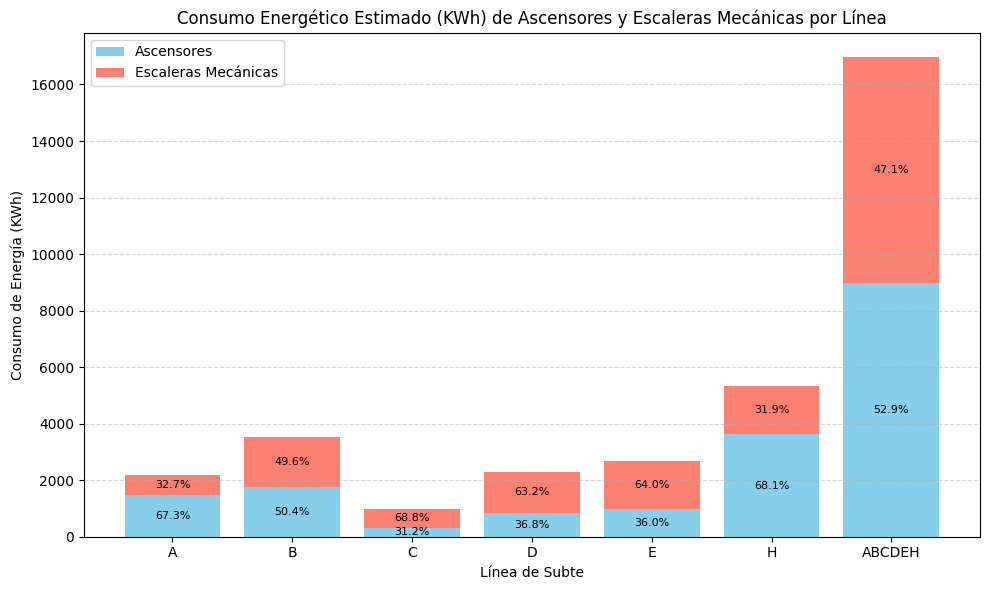

In [262]:
# Gráfico de barras apiladas: Consumo energético estimado en KWh por línea
plt.figure(figsize=(10,6))

# Barras: Consumo de ascensores
plt.bar(energia['linea'], energia['Consumo Ascensores (KWh)'], 
        color='skyblue', label='Ascensores')

# Barras: Consumo de escaleras mecánicas (apiladas sobre ascensores)
plt.bar(energia['linea'], energia['Consumo Escaleras Mecanicas (KWh)'], 
        color='salmon', label='Escaleras Mecánicas', 
        bottom=energia['Consumo Ascensores (KWh)'])

# Agregado de porcentajes sobre las barras
for i, row in energia.iterrows():
    total_kwh = row['Consumo Ascensores (KWh)'] + row['Consumo Escaleras Mecanicas (KWh)']
    if total_kwh > 0:
        plt.text(row['linea'], row['Consumo Ascensores (KWh)'] / 2, 
                 f"{row['Consumo Ascensores (KWh)'] / total_kwh * 100:.1f}%", 
                 ha='center', va='center', fontsize=8, color='black')
        plt.text(row['linea'], row['Consumo Ascensores (KWh)'] + row['Consumo Escaleras Mecanicas (KWh)'] / 2, 
                 f"{row['Consumo Escaleras Mecanicas (KWh)'] / total_kwh * 100:.1f}%", 
                 ha='center', va='center', fontsize=8, color='black')

# Configuración general del gráfico
plt.title('Consumo Energético Estimado (KWh) de Ascensores y Escaleras Mecánicas por Línea')
plt.xlabel('Línea de Subte')
plt.ylabel('Consumo de Energía (KWh)')
plt.legend()
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Mostrar gráfico
plt.show()

El siguiente grafico, muestra la evolución comparativa del consumo energético entre ascensores y escaleras mecánicas.

- Este gráfico de líneas permite analizar la tendencia relativa del consumo energético entre ascensores y escaleras mecánicas para cada línea. 
- Al representar ambas curvas sobre el mismo eje, es posible identificar líneas con mayor carga energética, desbalances, o potenciales oportunidades de optimización.

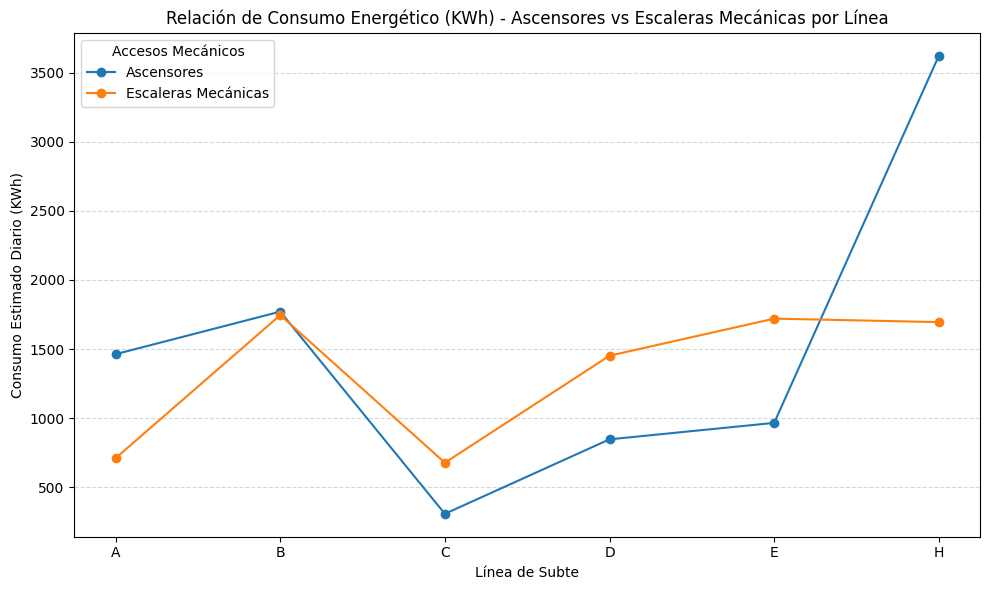

In [263]:
# Gráfico de líneas comparativo: consumo de ascensores vs escaleras mecánicas por línea
plt.figure(figsize=(10,6))

# Graficar líneas con etiquetas de eje X explícitas
plt.plot(energia2['linea'], energia2['consumo_asc_kwh'], marker='o', label='Ascensores')
plt.plot(energia2['linea'], energia2['consumo_esc_kwh'], marker='o', label='Escaleras Mecánicas')

# Títulos y etiquetas
plt.title('Relación de Consumo Energético (KWh) - Ascensores vs Escaleras Mecánicas por Línea')
plt.xlabel('Línea de Subte')
plt.ylabel('Consumo Estimado Diario (KWh)')
plt.legend(title='Accesos Mecánicos')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

# Mostrar gráfico
plt.show()

El siguiente código genera un gráfico de líneas que compara la cantidad total de ascensores y escaleras mecánicas por línea de subte.

- Permite visualizar las diferencias estructurales en infraestructura de accesibilidad entre líneas de subte, mostrando claramente cuáles están más equipadas con ascensores o escaleras mecánicas. 
- Es una herramienta útil para planificar mejoras de accesibilidad, mantenimiento o evaluación de distribución equitativa.

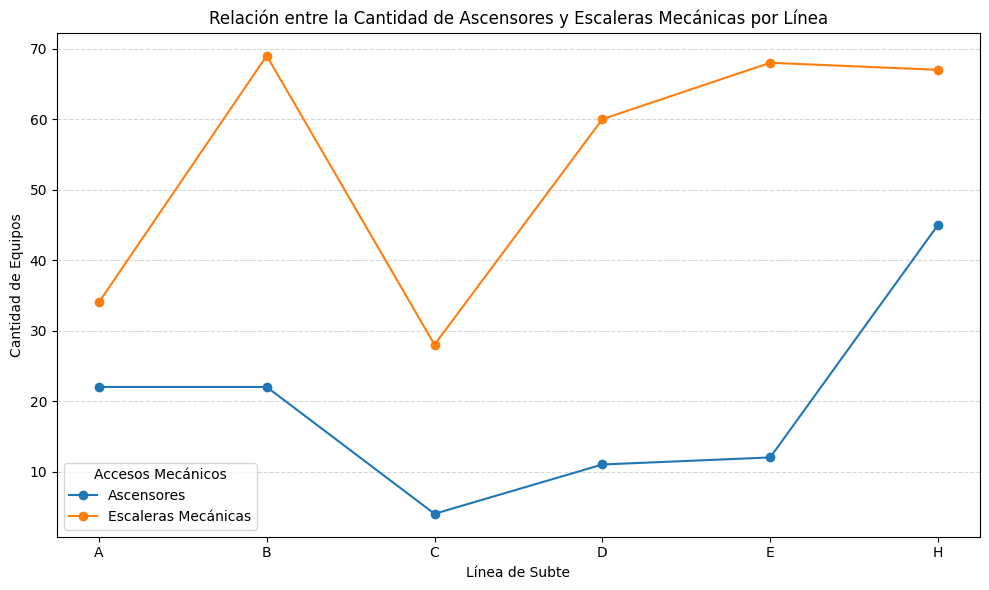

In [264]:
# Agrupar y sumar cantidad de ascensores y escaleras por línea
accesos_mecanicos = df.groupby('linea')[['ascensores', 'escaleras_mecanicas']].sum().reset_index()

# Gráfico de líneas con etiquetas de línea en el eje X
plt.figure(figsize=(10,6))
plt.plot(accesos_mecanicos['linea'], accesos_mecanicos['ascensores'], marker='o', label='Ascensores')
plt.plot(accesos_mecanicos['linea'], accesos_mecanicos['escaleras_mecanicas'], marker='o', label='Escaleras Mecánicas')

# Títulos y etiquetas
plt.title('Relación entre la Cantidad de Ascensores y Escaleras Mecánicas por Línea')
plt.xlabel('Línea de Subte')
plt.ylabel('Cantidad de Equipos')
plt.legend(title='Accesos Mecánicos')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

# Mostrar gráfico
plt.show()

In [265]:
df.columns

Index(['long', 'lat', 'linea', 'estacion', 'escaleras_mecanicas', 'ascensores', 'longitud_km', 'horas_diarias', 'consumo_ascensores_kwh', 'consumo_escaleras_mecanicas_kwh'], dtype='object')

## Analisis de Estaciones

In [266]:
est= df.groupby('estacion')[['ascensores','escaleras_mecanicas','consumo_ascensores_kwh', 'consumo_escaleras_mecanicas_kwh']].sum()

In [267]:
import matplotlib.pyplot as plt 

En el siguiente código, agrupo el DataFrame "df" por nombre de estación y calculo la suma total por estación de:
1. •	Cantidad de ascensores
2. •	Cantidad de escaleras mecánicas
3. •	Consumo energético estimado de ascensores (kWh)
4. •	Consumo energético estimado de escaleras mecánicas (kWh)


Este agrupamiento consolida los datos por estación, permitiendo obtener un perfil energético y de accesibilidad mecánica por estación individual. 

Es una base útil para identificar:
1. •	Estaciones con mayor carga energética
2. •	Infraestructura instalada
3. •	Oportunidades de mejora en accesibilidad

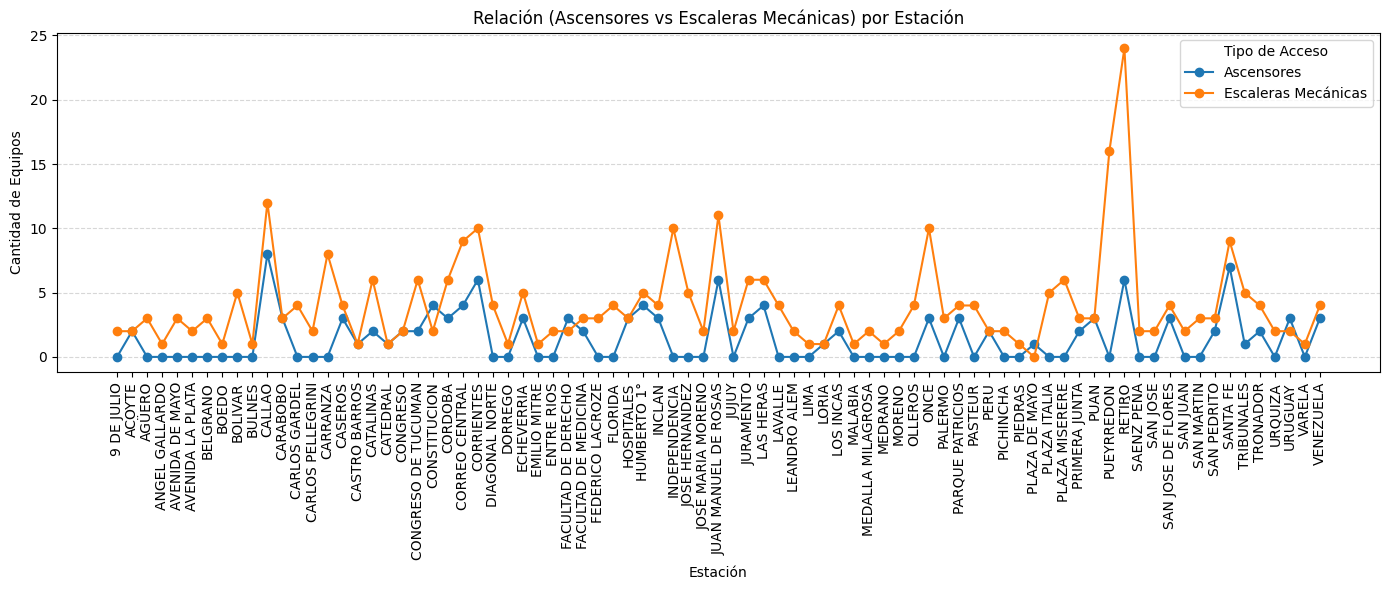

In [268]:
# Gráfico de líneas: relación entre ascensores y escaleras mecánicas por estación
plt.figure(figsize=(14,6))
plt.plot(est.index, est['ascensores'], marker='o', label='Ascensores')
plt.plot(est.index, est['escaleras_mecanicas'], marker='o', label='Escaleras Mecánicas')

# Título y etiquetas
plt.title('Relación (Ascensores vs Escaleras Mecánicas) por Estación')
plt.xlabel('Estación')
plt.ylabel('Cantidad de Equipos')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Tipo de Acceso')
plt.tight_layout()

# Mostrar gráfico
plt.show()

El siguiente gráfico de líneas muestra la relación del consumo energético estimado diario (en kWh) de ascensores y escaleras mecánicas, para cada estación del subte.

- De este grafico, se puede analizar lo siguiente:
1. •	Qué estaciones tienen mayor o menor consumo energético.
2. •	Cómo se distribuye el consumo entre ascensores y escaleras.
3. •	Detectar estaciones con infraestructura más demandante (muchos equipos o uso intensivo).
4. •	Si hay estaciones que carecen de alguno de los dos medios (líneas en cero).

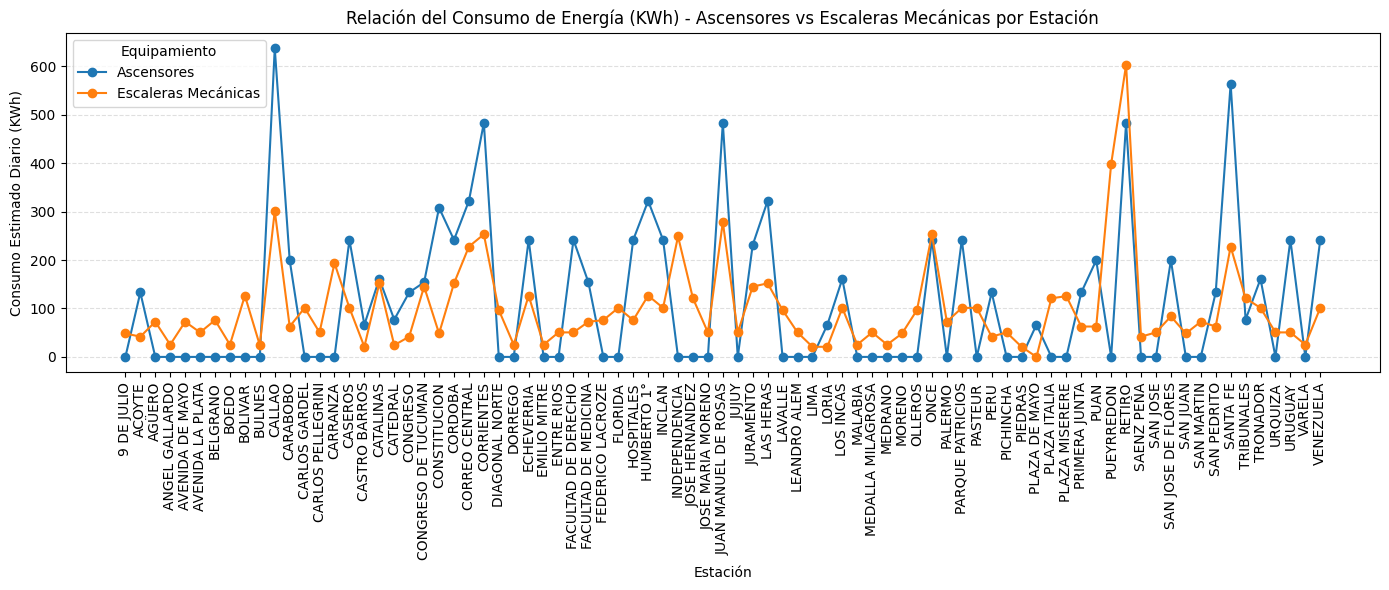

In [270]:
# Gráfico de líneas: Consumo energético por estación
plt.figure(figsize=(14,6))
plt.plot(est.index, est['consumo_ascensores_kwh'], marker='o', label='Ascensores')
plt.plot(est.index, est['consumo_escaleras_mecanicas_kwh'], marker='o', label='Escaleras Mecánicas')

# Títulos y etiquetas
plt.title('Relación del Consumo de Energía (KWh) - Ascensores vs Escaleras Mecánicas por Estación')
plt.xlabel('Estación')
plt.ylabel('Consumo Estimado Diario (KWh)')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend(title='Equipamiento')
plt.tight_layout()

# Mostrar gráfico
plt.show()

**Idem anterior . TOP 20**

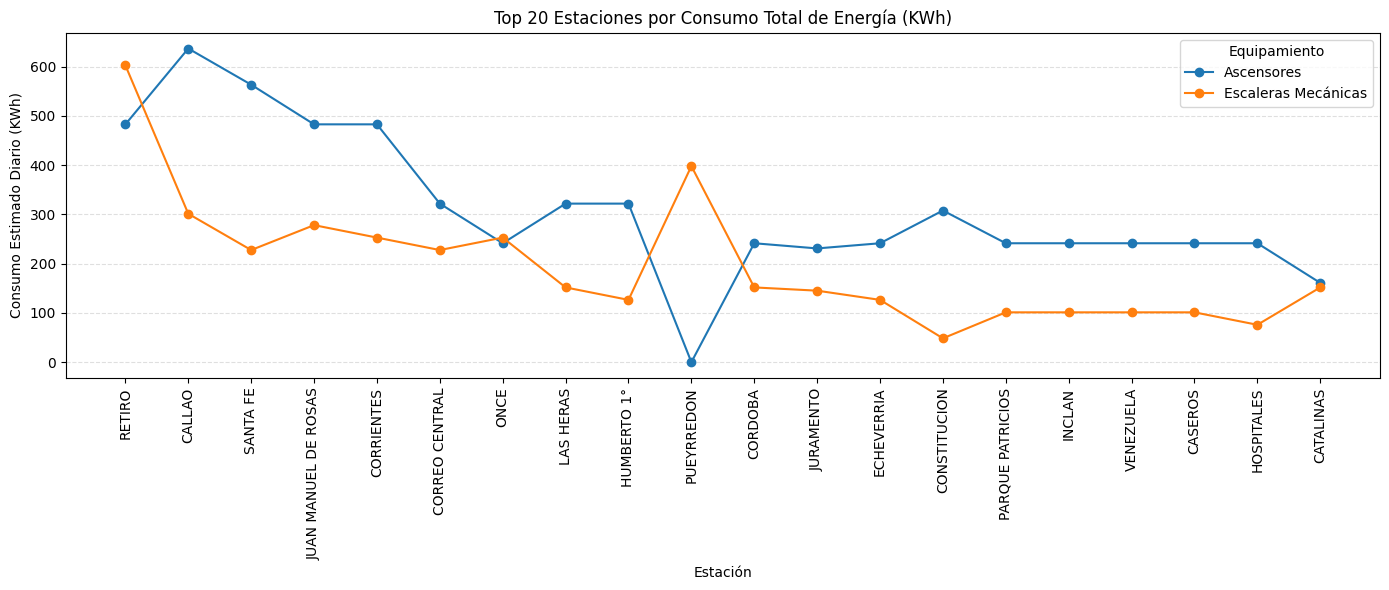

In [272]:
# 1. Agregamos una columna con el consumo total por estación
est['total_consumo_kwh'] = est['consumo_ascensores_kwh'] + est['consumo_escaleras_mecanicas_kwh']

# 2. Seleccionamos las 20 estaciones con mayor consumo
top20 = est.sort_values(by='total_consumo_kwh', ascending=False).head(20)

# 3. Gráfico de líneas para las top 20 estaciones
plt.figure(figsize=(14,6))
plt.plot(top20.index, top20['consumo_ascensores_kwh'], marker='o', label='Ascensores')
plt.plot(top20.index, top20['consumo_escaleras_mecanicas_kwh'], marker='o', label='Escaleras Mecánicas')

# Títulos y formato
plt.title('Top 20 Estaciones por Consumo Total de Energía (KWh)')
plt.xlabel('Estación')
plt.ylabel('Consumo Estimado Diario (KWh)')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend(title='Equipamiento')
plt.tight_layout()

# Mostrar gráfico
plt.show()

En el siguiente código muestro un ranking de estaciones con mayor consumo energético, tanto para ascensores como para escaleras mecánicas. 

In [274]:
# Ranking de Estaciones con MAYOR consumo KWh por Ascensores
dftotal = df.sort_values(by='consumo_ascensores_kwh', ascending=False)
print(f'Ranking TOP {ranking} de Estaciones con MAYOR consumo KWh por Ascensores')
print(dftotal[['linea', 'estacion', 'consumo_ascensores_kwh']].head(ranking).to_string(justify='all'))

print()

# Ranking de Estaciones con MAYOR consumo KWh por Escaleras Mecánicas
dftotal = df.sort_values(by='consumo_escaleras_mecanicas_kwh', ascending=False)
print(f'Ranking TOP {ranking} de Estaciones con MAYOR consumo KWh por Escaleras Mecánicas')
print(dftotal[['linea', 'estacion', 'consumo_escaleras_mecanicas_kwh']].head(ranking).to_string(justify='all'))

Ranking TOP 10 de Estaciones con MAYOR consumo KWh por Ascensores
   linea              estacion  consumo_ascensores_kwh
91  H                 SANTA FE  563.5                 
24  B     JUAN MANUEL DE ROSAS  483.0                 
83  H               CORRIENTES  483.0                 
67  E           CORREO CENTRAL  322.0                 
86  H              HUMBERTO 1°  322.0                 
88  H                LAS HERAS  322.0                 
35  C             CONSTITUCION  308.0                 
92  H                VENEZUELA  241.5                 
89  H                     ONCE  241.5                 
21  B               ECHEVERRIA  241.5                 

Ranking TOP 10 de Estaciones con MAYOR consumo KWh por Escaleras Mecánicas
   linea              estacion  consumo_escaleras_mecanicas_kwh
24  B     JUAN MANUEL DE ROSAS  278.3                          
83  H               CORRIENTES  253.0                          
77  E                   RETIRO  253.0                        

**#VISUALIZACION DE ESTACIONES QUE APARECEN EN MULTIPLES LINEAS**

- ESTO DEMUESTRA QUE NO SON DUPLICADAS, SINO QUE SE COMPARTEN EN VARIAS LINEAS.
- POR ESO SE REPITEN EN EL DATAFRAME.
- SE PUEDE VER EN LOS GRAFICOS SIGUIENTES CON LOS CRUCES DE LINEAS.

In [51]:
print('Estaciones cuyos Nombres se comparten con otras Lineas. Por eso se repiten. NO significa que sean duplicadas.')
print('Estas estaciones se veran reflejadas en los graficos con los cruces de las lineas')
dfkwhordenado = df.sort_values(by='estacion', ascending=False)
estacionesrepetidas = df[df.duplicated(subset='estacion', keep=False)]
estacionesrepetidas = estacionesrepetidas.sort_values(by='linea', ascending=True)
print(estacionesrepetidas.to_string())

Estaciones cuyos Nombres se comparten con otras Lineas. Por eso se repiten. NO significa que sean duplicadas.
Estas estaciones se veran reflejadas en los graficos con los cruces de las lineas
         long        lat linea       estacion  escaleras_mecanicas  ascensores  longitud_km  horas_diarias  consumo_ascensores_kwh  consumo_escaleras_mecanicas_kwh
31 -58.402395 -34.594426     B     PUEYRREDON                    5           0    13.906191             23                     0.0                            126.5
30 -58.405399 -34.604581     B     PUEYRREDON                    5           0    13.906191             23                     0.0                            126.5
17 -58.393125 -34.599640     B         CALLAO                    5           3    13.906191             23                   241.5                            126.5
16 -58.392314 -34.604420     B         CALLAO                    5           3    13.906191             23                   241.5                      

In [275]:
agrupadas = estacionesrepetidas.groupby('estacion')[['linea']].agg(list)
print(agrupadas)

                      linea
estacion                   
CALLAO         [B, B, D, D]
INDEPENDENCIA  [C, C, E, E]
PUEYRREDON     [B, B, D, D]
RETIRO         [C, C, E, E]


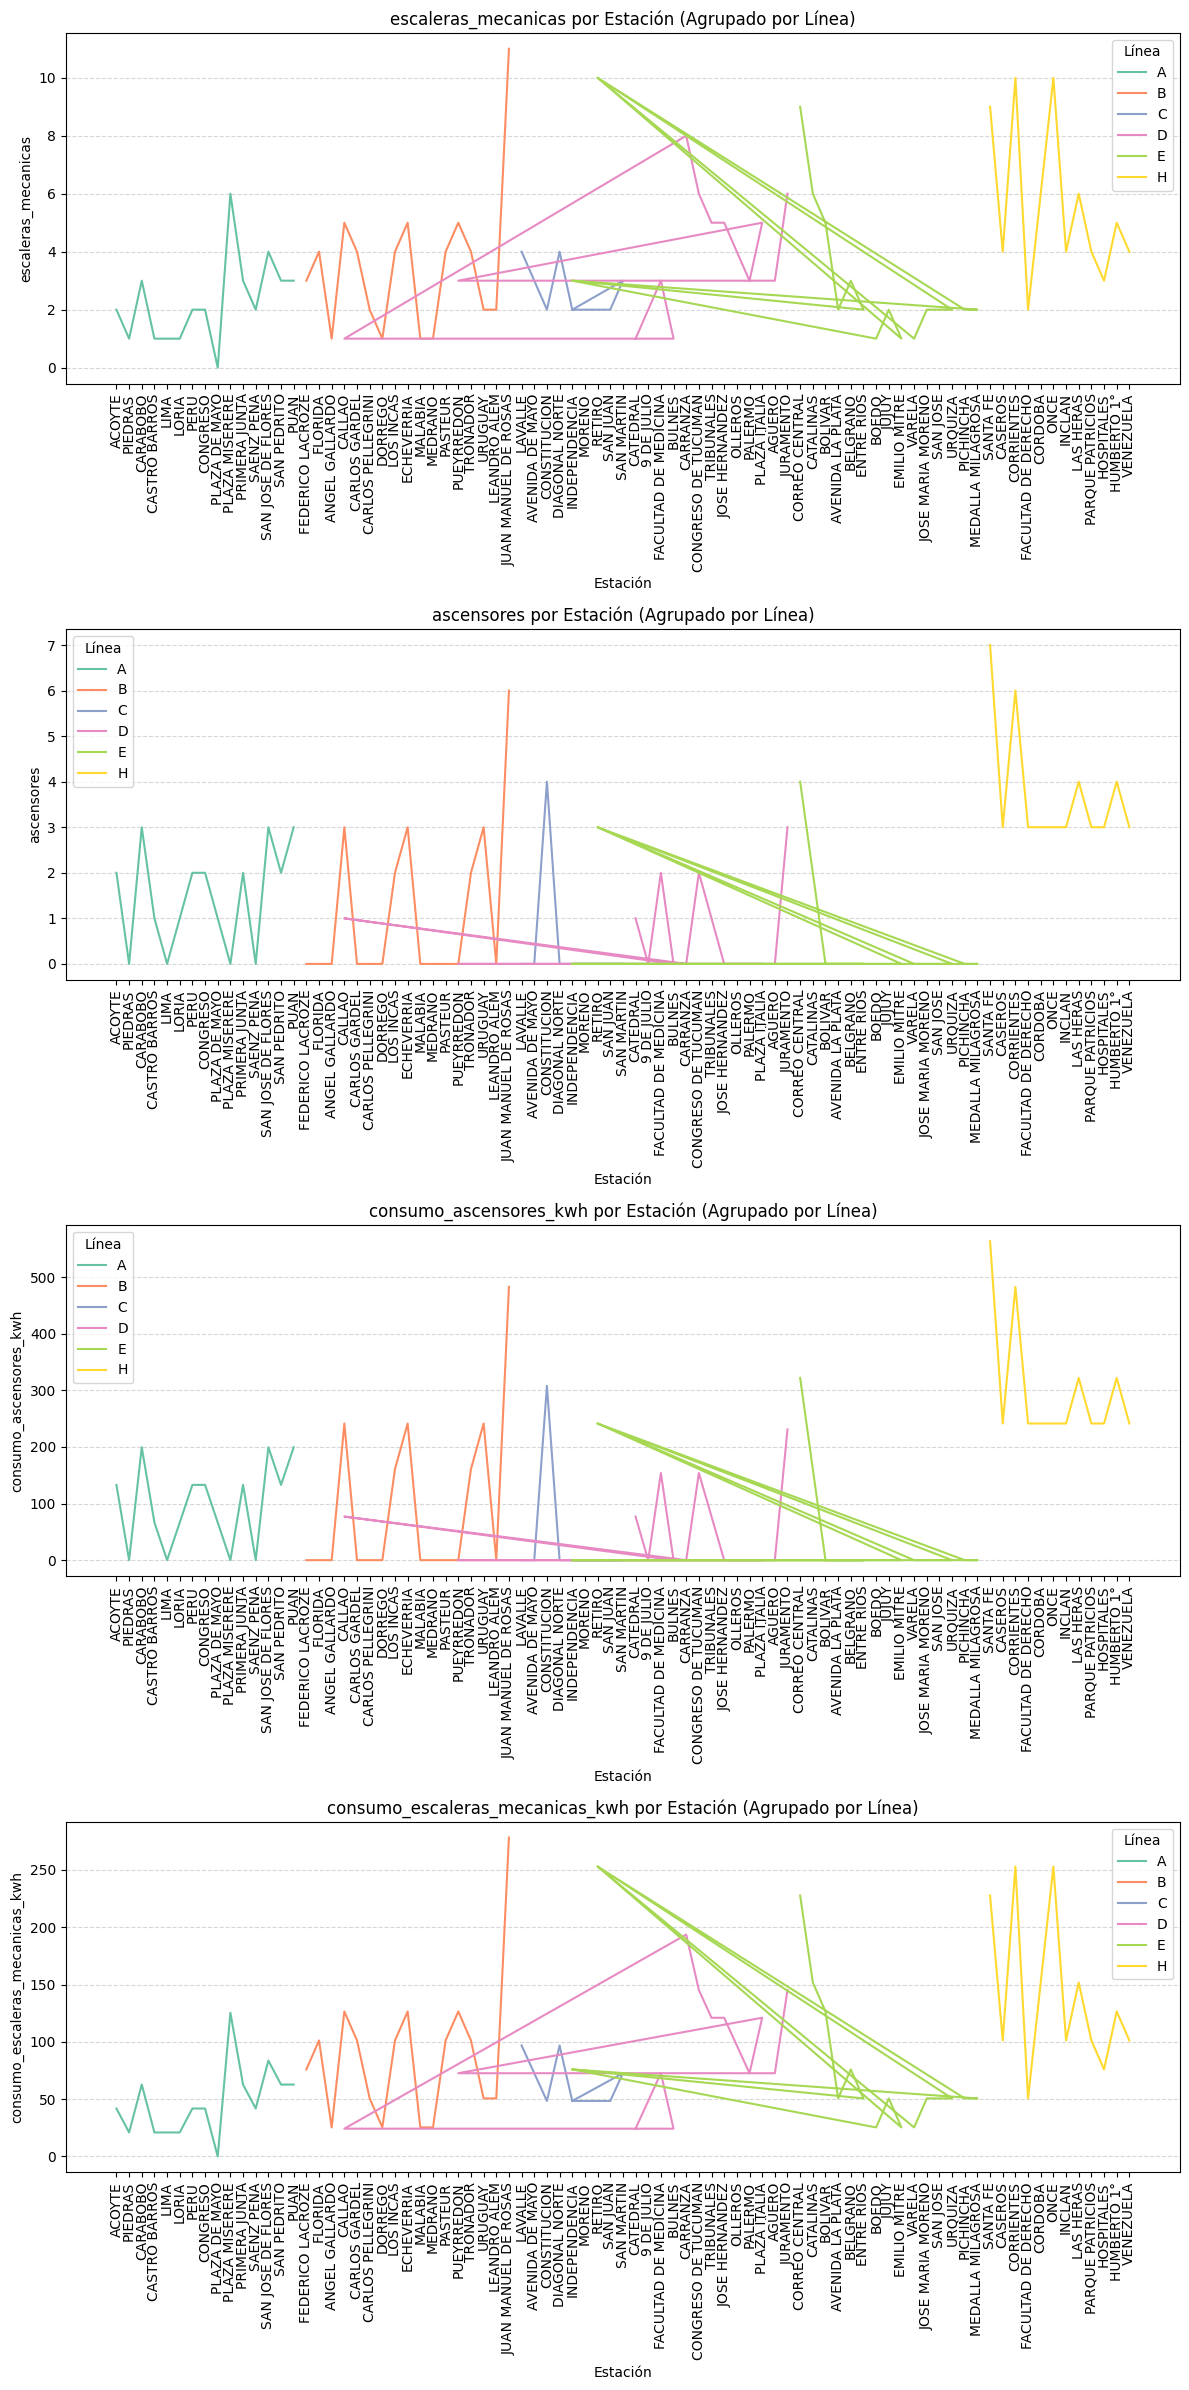

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ordeno por línea
dfkwhordenado = df.sort_values(by='linea', ascending=True)

# Columnas a graficar
columnas = ['escaleras_mecanicas', 'ascensores', 'consumo_ascensores_kwh', 'consumo_escaleras_mecanicas_kwh']

# Paleta de colores para líneas
lineas = dfkwhordenado['linea'].unique()
palette = sns.color_palette("Set2", len(lineas))

# Creo subgráficos
fig, axs = plt.subplots(nrows=len(columnas), figsize=(12, 6*len(columnas)))

# Itera por cada columna
for i, columna in enumerate(columnas):
    for j, linea in enumerate(lineas):
        # Filtro por línea
        df_linea = dfkwhordenado[dfkwhordenado['linea'] == linea]
        
        # Grafico la columna correspondiente
        axs[i].plot(df_linea['estacion'], df_linea[columna], label=linea, color=palette[j])
    
    axs[i].set_title(f'{columna} por Estación (Agrupado por Línea)')
    axs[i].set_xlabel('Estación')
    axs[i].set_ylabel(columna)
    axs[i].tick_params(axis='x', rotation=90)
    axs[i].grid(axis='y', linestyle='--', alpha=0.5)
    axs[i].legend(title='Línea')

plt.tight_layout()
plt.show()

**INGRESAR LA LETRA DE LA LINEA QUE SE DESEA ANALIZAR**

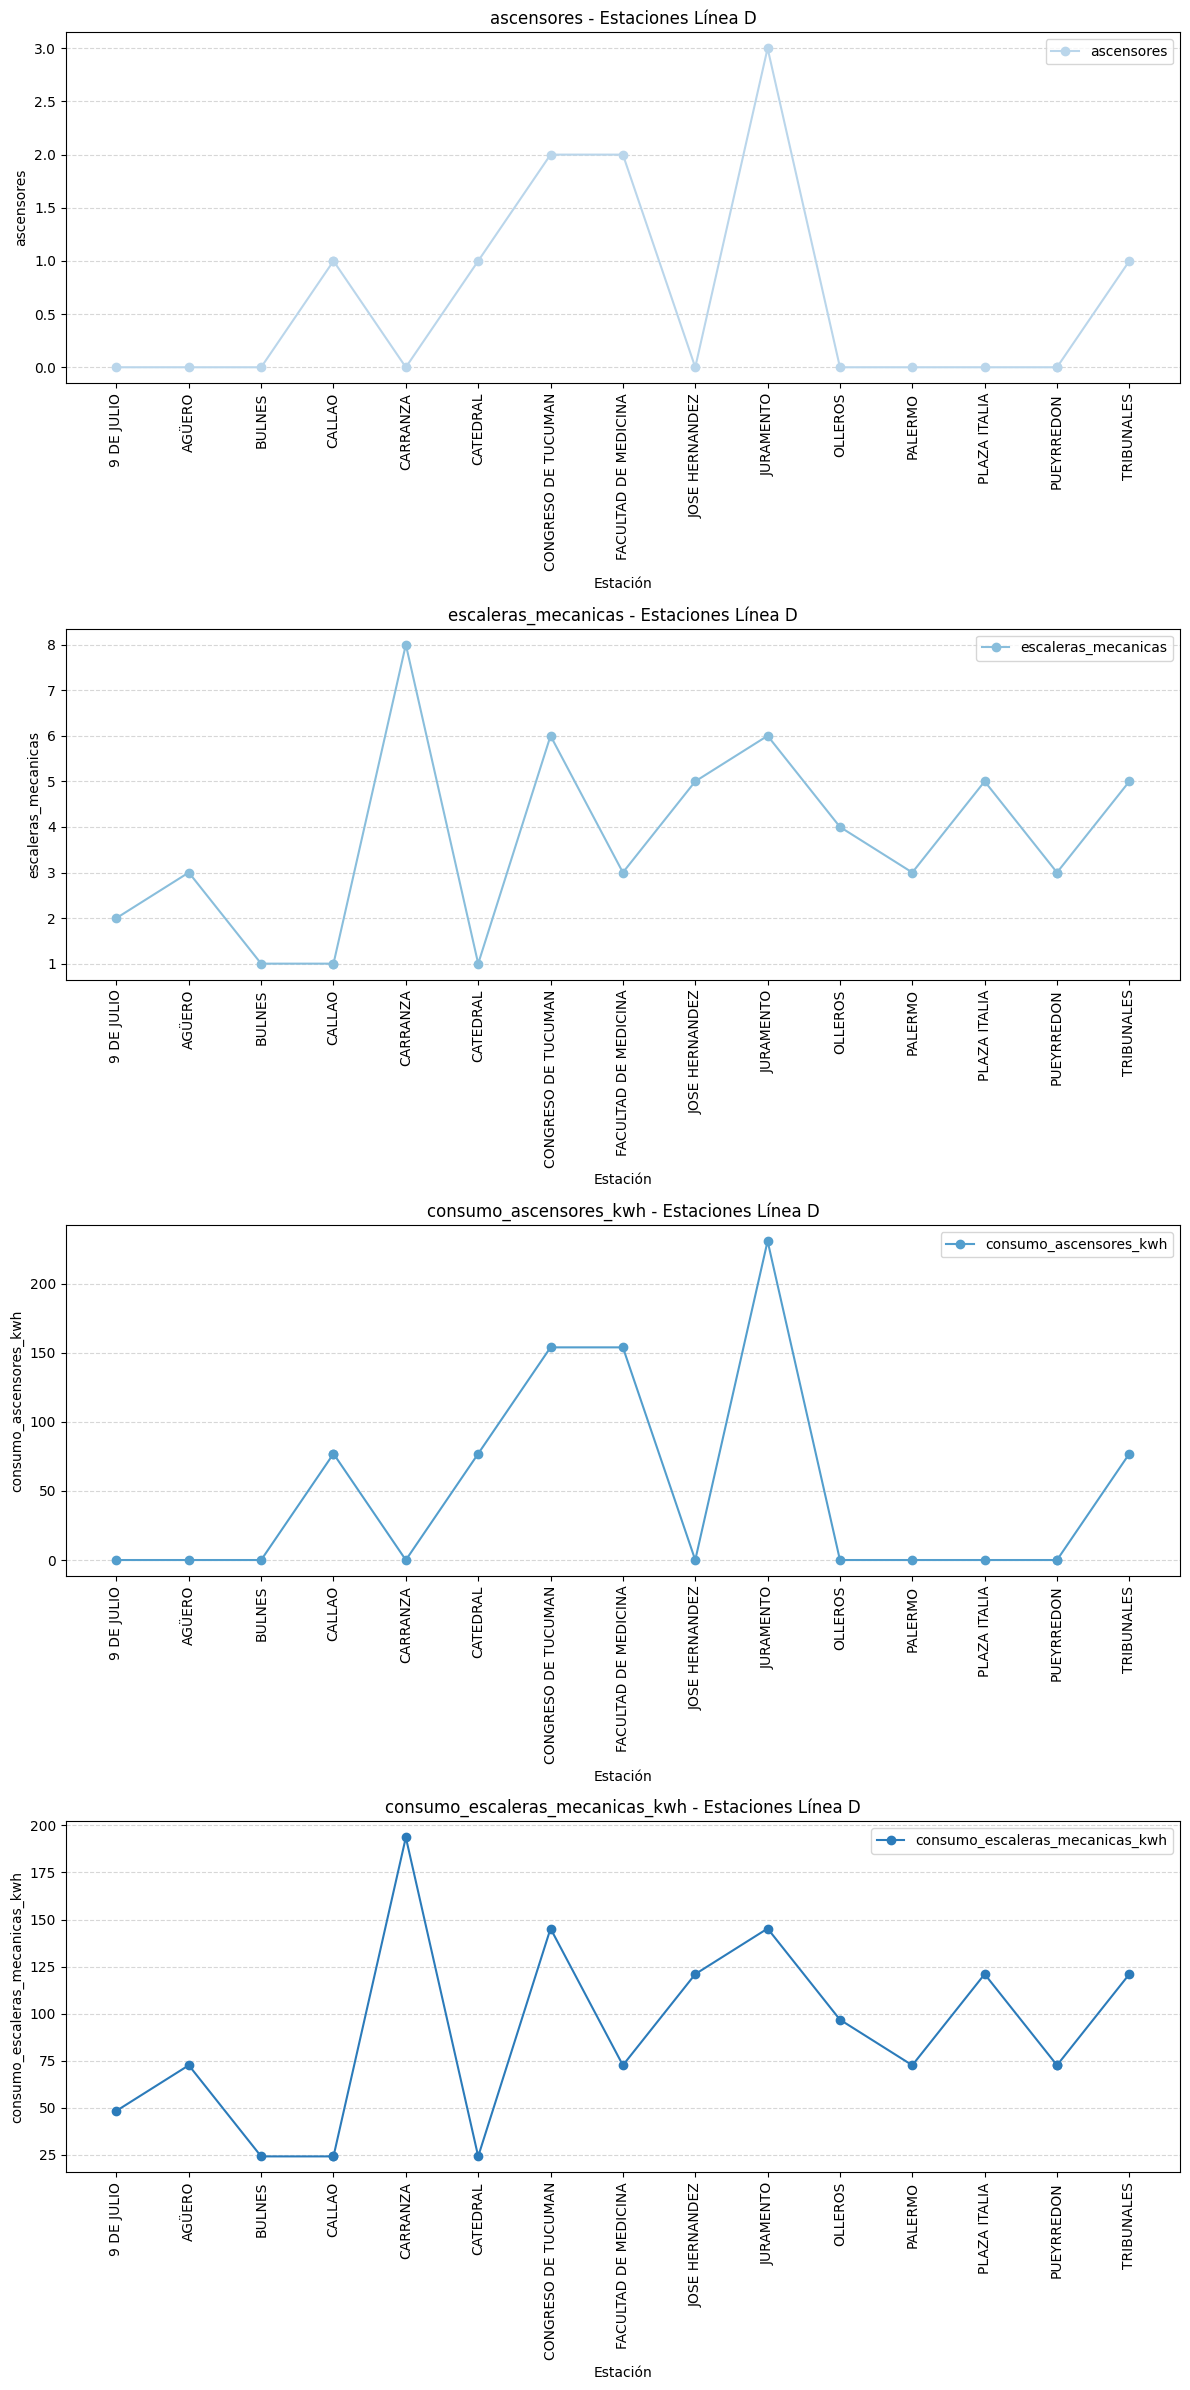

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Parámetro: línea específica a visualizar
linea_especifica = 'D'

# Se Filtra el DataFrame por esa línea
df_linea = df[df['linea'] == linea_especifica].sort_values(by='estacion')

# Columnas a graficar
columnas = ['ascensores', 'escaleras_mecanicas', 'consumo_ascensores_kwh', 'consumo_escaleras_mecanicas_kwh']

# Paleta de color (azules)
color = sns.color_palette("Blues", len(columnas) + 2)

# Subgráficos
fig, axs = plt.subplots(nrows=len(columnas), figsize=(12, 6*len(columnas)))

# Recorre cada columna
for i, columna in enumerate(columnas):
    axs[i].plot(df_linea['estacion'], df_linea[columna], marker='o', color=color[i+1], label=columna)
    axs[i].set_title(f'{columna} - Estaciones Línea {linea_especifica}')
    axs[i].set_xlabel('Estación')
    axs[i].set_ylabel(columna)
    axs[i].tick_params(axis='x', rotation=90)
    axs[i].grid(axis='y', linestyle='--', alpha=0.5)
    axs[i].legend()

plt.tight_layout()

# Muestro el gráfico
plt.show()

# Se Guarda una imagen del grafico resultante.
fig.savefig(f'consumo_linea_{linea_especifica}.png', dpi=300)

In [278]:
energia.head(10)

,linea,Total Ascensores,Consumo Ascensores (KWh),Total Escaleras Mecanicas,Consumo Escaleras Mecanicas (KWh)
0,A,22,1463.0,34,710.6
1,B,22,1771.0,69,1745.7
2,C,4,308.0,28,677.6
3,D,11,847.0,60,1452.0
4,E,12,966.0,68,1720.4
5,H,45,3622.5,67,1695.1
Total,ABCDEH,116,8977.5,326,8001.4


**#Visualizacion unificado por linea.**

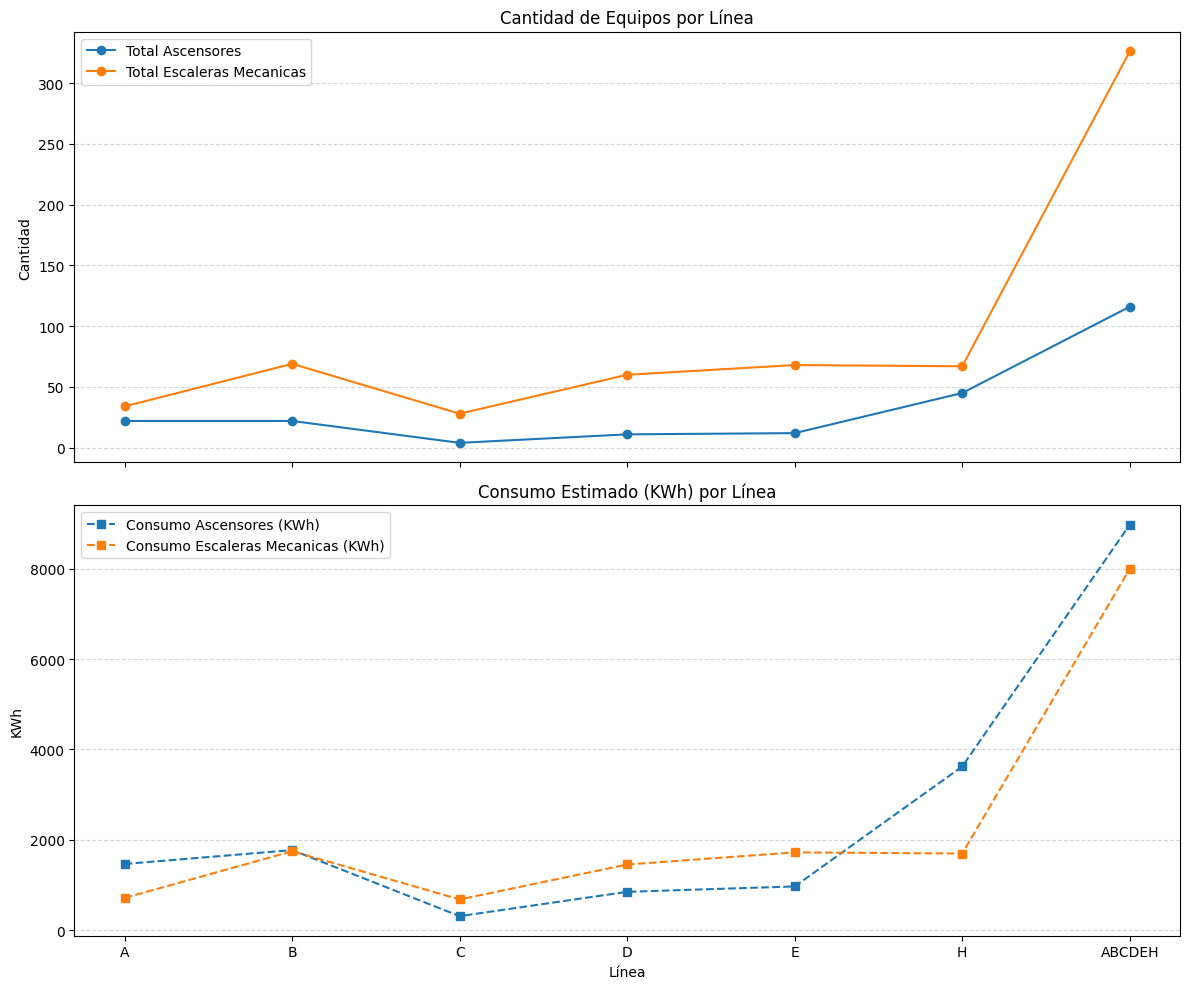

In [280]:
import matplotlib.pyplot as plt

# Columnas divididas por tipo
columnas_equipos = ['Total Ascensores', 'Total Escaleras Mecanicas']
columnas_consumo = ['Consumo Ascensores (KWh)', 'Consumo Escaleras Mecanicas (KWh)']

# Creo figura con 2 subplots
fig, axs = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Primer gráfico: cantidad de equipos
for columna in columnas_equipos:
    axs[0].plot(energia['linea'], energia[columna], marker='o', label=columna)
axs[0].set_title('Cantidad de Equipos por Línea')
axs[0].set_ylabel('Cantidad')
axs[0].legend()
axs[0].grid(axis='y', linestyle='--', alpha=0.5)

# Segundo gráfico: consumo energético
for columna in columnas_consumo:
    axs[1].plot(energia['linea'], energia[columna], marker='s', linestyle='--', label=columna)
axs[1].set_title('Consumo Estimado (KWh) por Línea')
axs[1].set_xlabel('Línea')
axs[1].set_ylabel('KWh')
axs[1].legend()
axs[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Analisis de Cantidad de Ascensores y Escaleras Mecanicas para una Linea especifica a Eleccion**

- Se debera ingresar la letra ded la Linea que se desea visualizar.

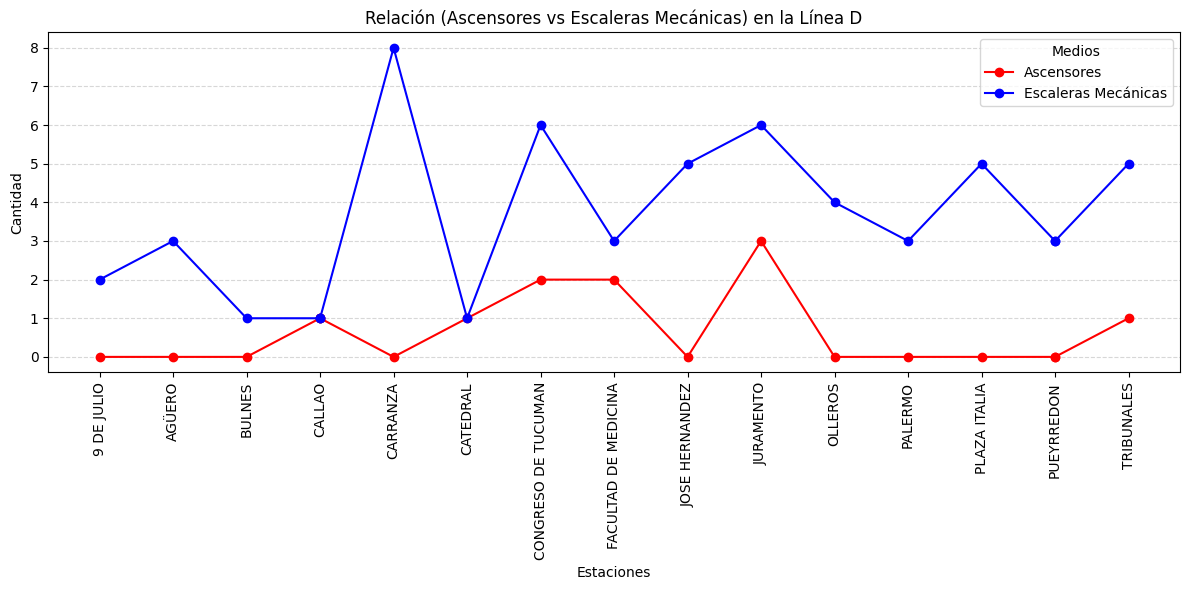

In [296]:
# Relación (Ascensores Vs Escaleras Mecánicas) en la Línea específica
# INGRESAR LÍNEA (A,B,C,D,E,H)
linea = 'D'

# Filtrar datos
linea_data = df[df['linea'] == linea].sort_values(by='estacion')

# Crear gráfico
plt.figure(figsize=(12, 6))
plt.plot(linea_data['estacion'], linea_data['ascensores'], marker='o', label='Ascensores', color='red')
plt.plot(linea_data['estacion'], linea_data['escaleras_mecanicas'], marker='o', label='Escaleras Mecánicas', color='blue')

# Personalización
plt.title(f'Relación (Ascensores vs Escaleras Mecánicas) en la Línea {linea}')
plt.xlabel('Estaciones')
plt.ylabel('Cantidad')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Medios')
plt.tight_layout()

# Mostrar gráfico
plt.show()

**Apertura de graficos por linea.**

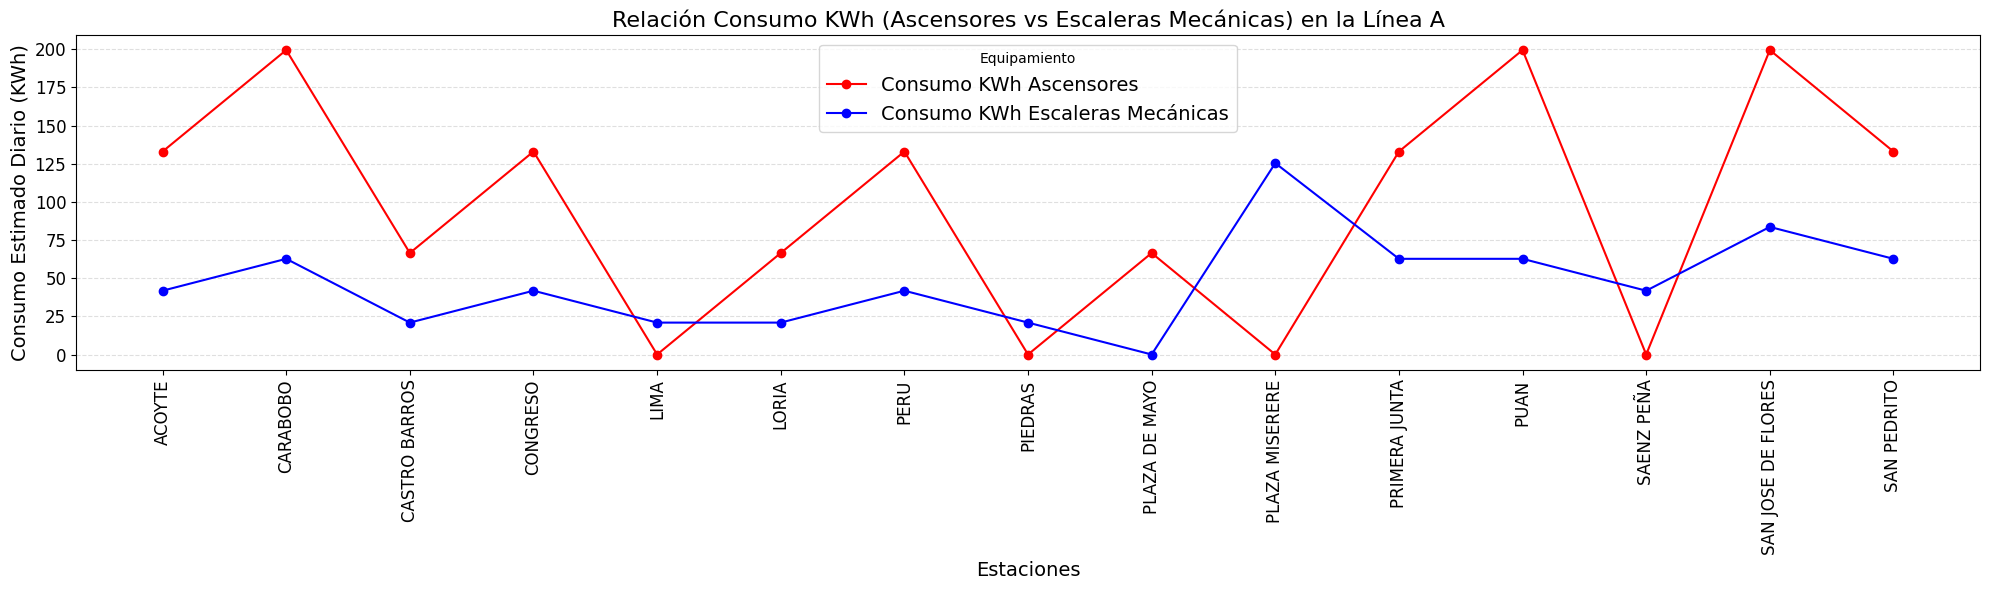

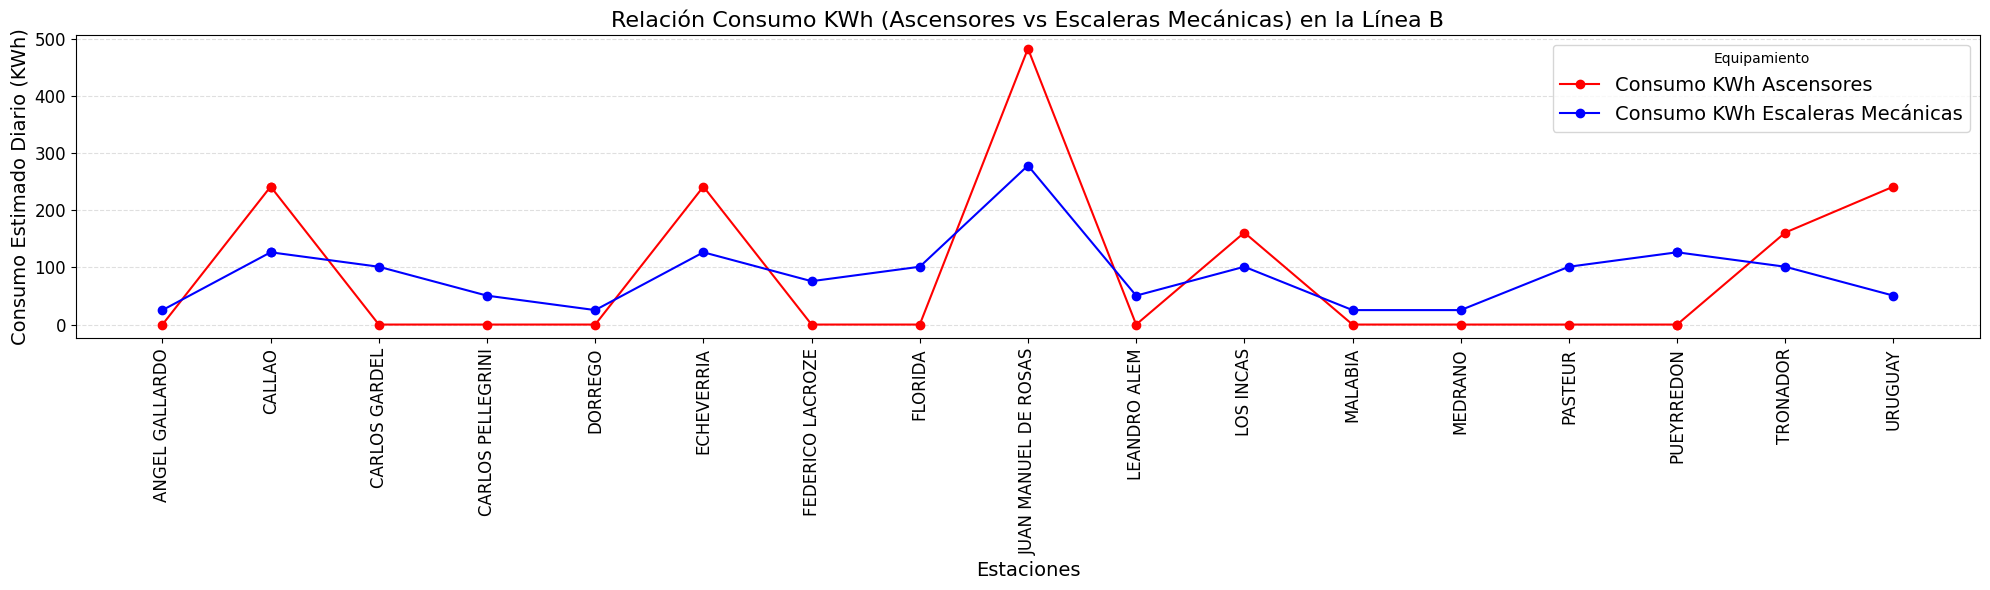

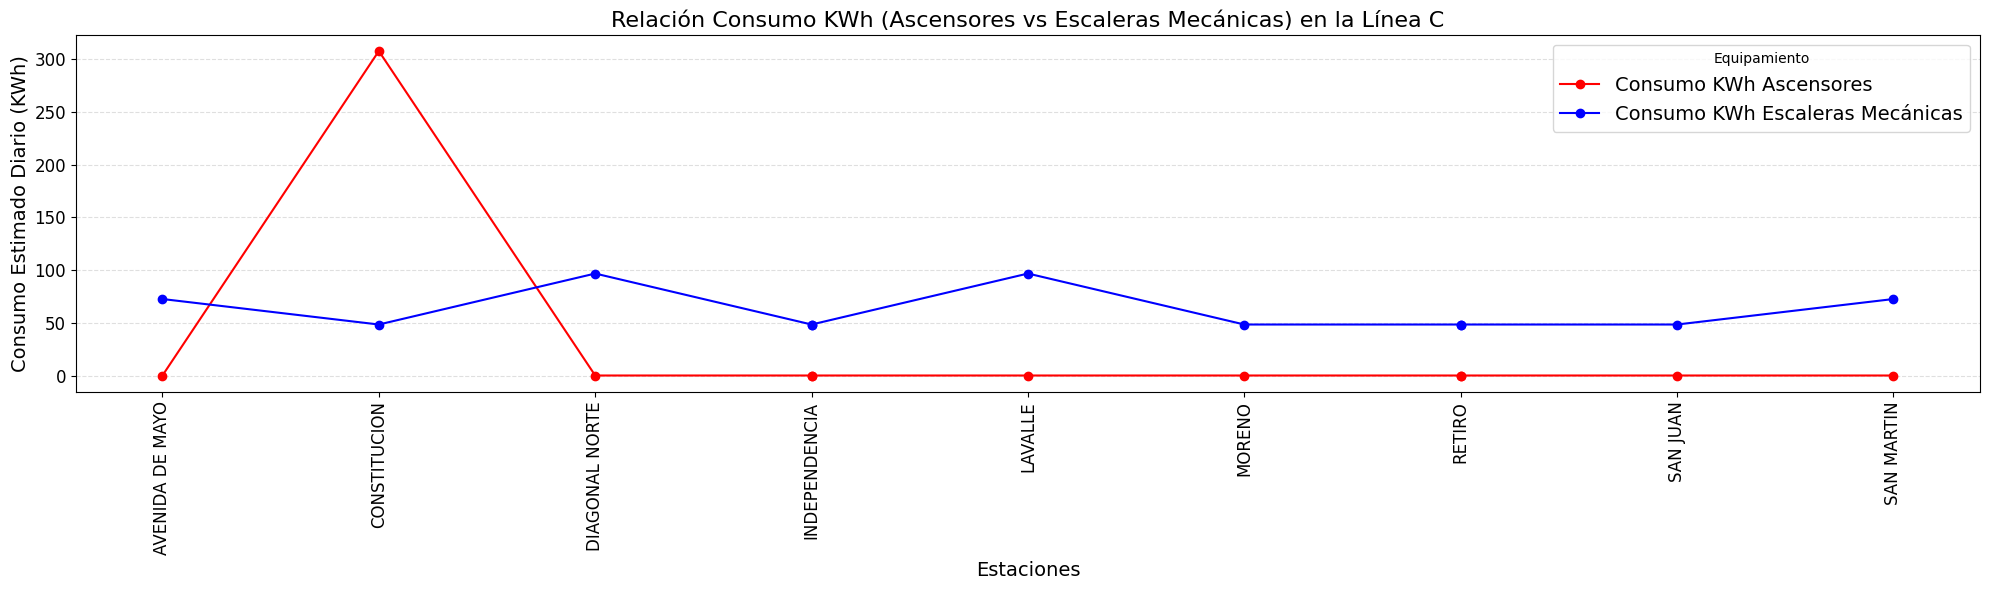

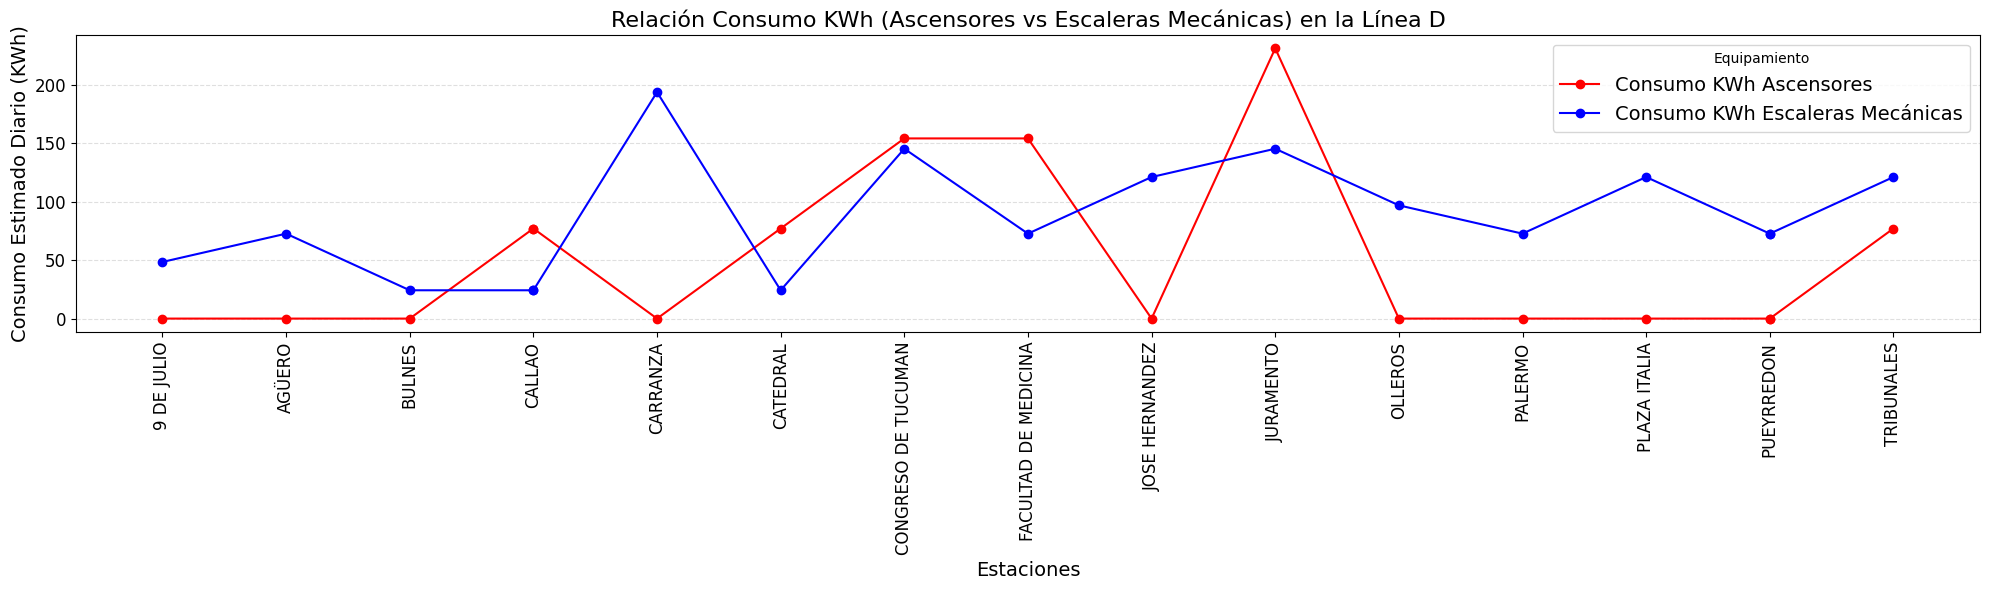

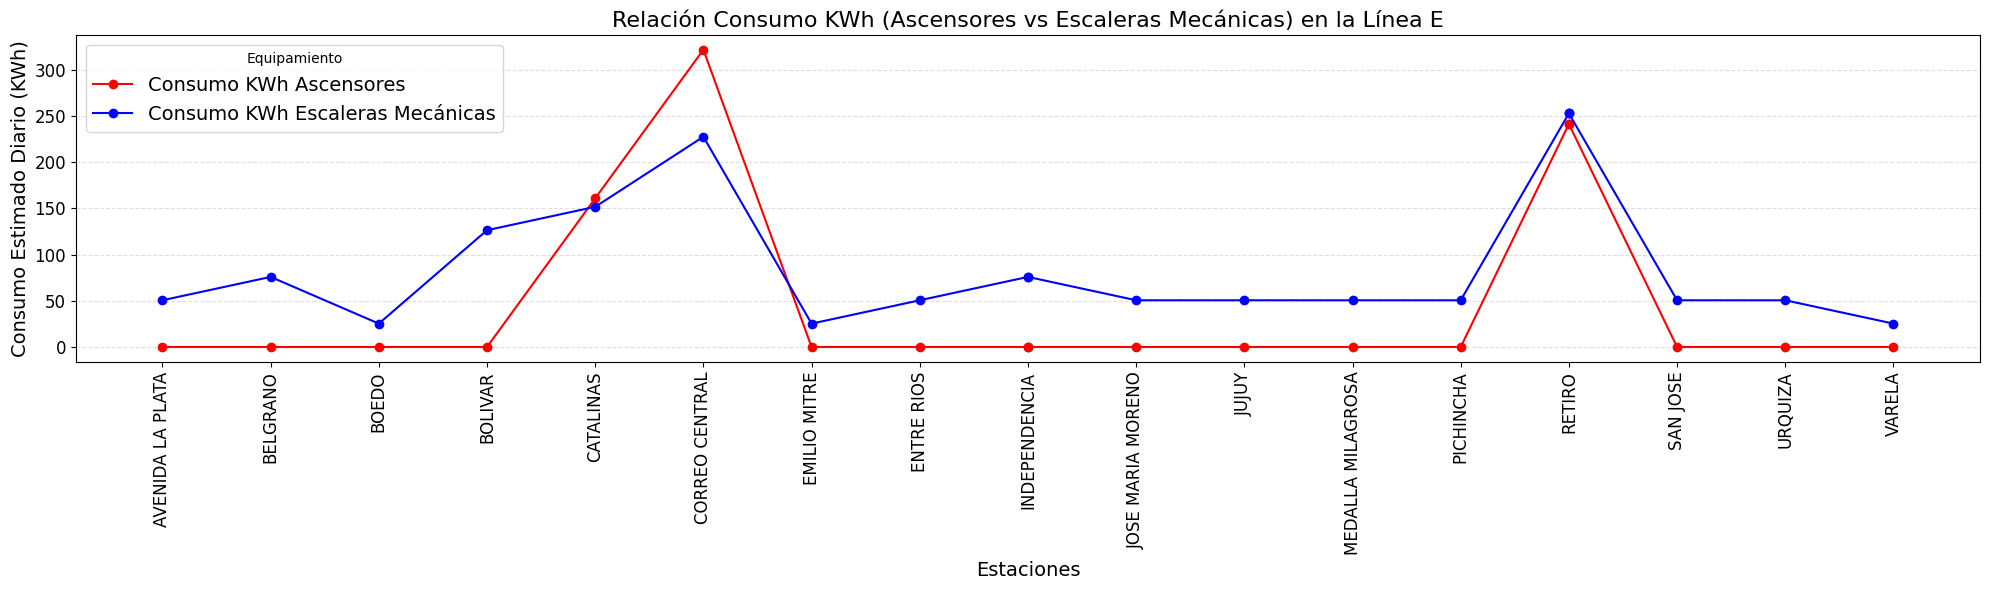

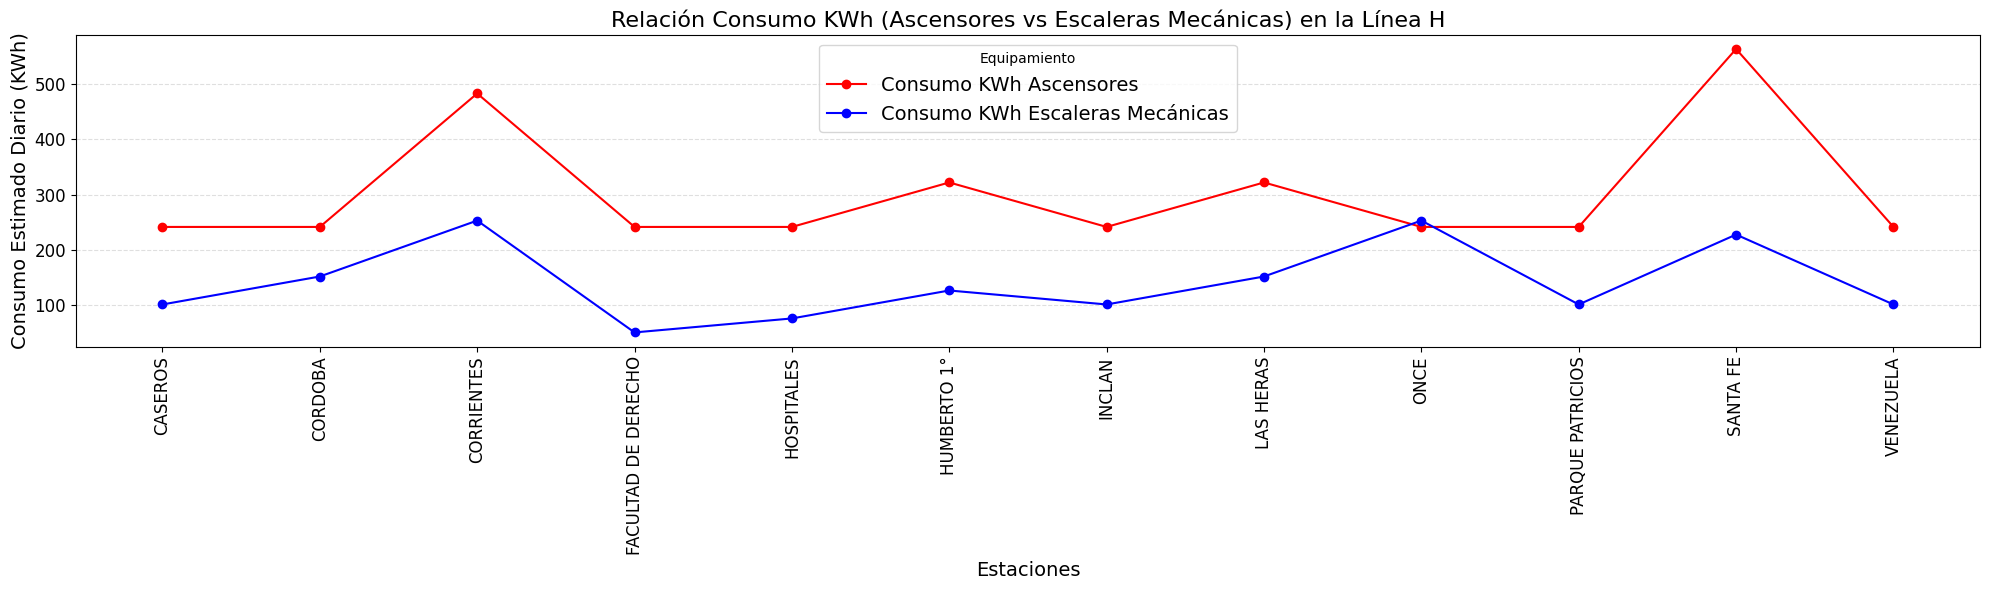

ROJO = Ascensores / AMARILLO = Escaleras Mecánicas


In [295]:
import matplotlib.pyplot as plt

# Relación Consumo KWh (Ascensores Vs Escaleras Mecánicas) por Línea

# Crear un gráfico individual por cada línea
for linea in df['linea'].unique():
    linea_data = df[df['linea'] == linea].sort_values(by='estacion')
    
    # Crear la figura y el gráfico para esta línea
    plt.figure(figsize=(20, 6))

    # Graficar Ascensores y Escaleras Mecánicas
    plt.plot(linea_data['estacion'], linea_data['consumo_ascensores_kwh'], label='Consumo KWh Ascensores', color='red', marker='o')
    plt.plot(linea_data['estacion'], linea_data['consumo_escaleras_mecanicas_kwh'], label='Consumo KWh Escaleras Mecánicas', color='blue', marker='o')
    
    # Títulos y etiquetas
    plt.title(f'Relación Consumo KWh (Ascensores vs Escaleras Mecánicas) en la Línea {linea}', fontsize=16)
    plt.xlabel('Estaciones', fontsize=14)
    plt.ylabel('Consumo Estimado Diario (KWh)', fontsize=14)
    plt.xticks(rotation=90, fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.4)

    # Leyenda
    plt.legend(title='Equipamiento', fontsize=14)
    
    # Ajuste del diseño
    plt.tight_layout()

    # Mostrar el gráfico
    plt.show()

print('ROJO = Ascensores / AMARILLO = Escaleras Mecánicas')

**Analisis de "CONSUMO Kwh" de Ascensores y Escaleras Mecanicas para una Linea especifica a Eleccion**

- Se debera ingresar la letra ded la Linea que se desea visualizar.

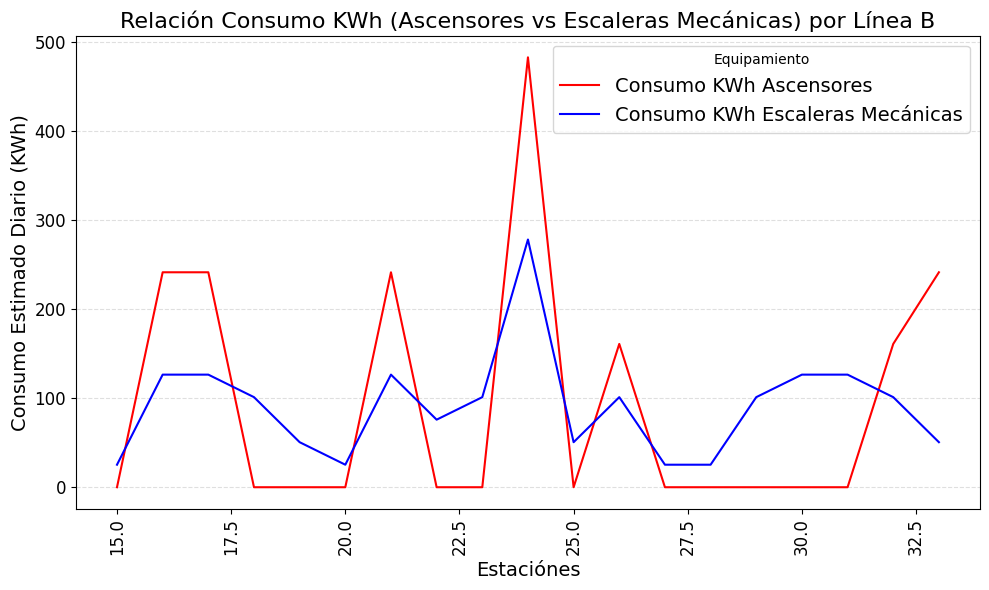

In [294]:
# Elegir Línea para analizar: (A, B, C, D, E, H)

# Ingresar línea a analizar
linea = 'B'

# Filtrar los datos correspondientes a la línea seleccionada
linea_data = df[df['linea'] == linea]

# Ordenar las estaciones por nombre
linea_data = linea_data.sort_values(by='estacion')

# Crear gráfico de líneas
plt.figure(figsize=(10,6))

# Graficar el consumo de KWh para ascensores y escaleras mecánicas
plt.plot(linea_data['consumo_ascensores_kwh'], label='Consumo KWh Ascensores', color='red')
plt.plot(linea_data['consumo_escaleras_mecanicas_kwh'], label='Consumo KWh Escaleras Mecánicas', color='blue')

# Títulos y etiquetas
plt.title(f'Relación Consumo KWh (Ascensores vs Escaleras Mecánicas) por Línea {linea}', fontsize=16)
plt.xlabel('Estaciónes', fontsize=14)
plt.ylabel('Consumo Estimado Diario (KWh)', fontsize=14)
plt.xticks(rotation=90, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Leyenda
plt.legend(title='Equipamiento', fontsize=14)

# Mostrar el gráfico
plt.tight_layout()
plt.show()

**TOTAL por LINEA : Ascensores, Escaleras Mecanicas y consumo en Kwh**

In [297]:
#Suma de Ascensores, Escaleras y Consumos por Linea. 
energia=df.groupby('linea')[['ascensores','consumo_ascensores_kwh','escaleras_mecanicas','consumo_escaleras_mecanicas_kwh']].sum().reset_index()
#Coloca titulos y Columnas con Total General de Ascensores, Escaleras y Consumos por Linea.
energia = energia.rename(columns={'ascensores': 'Total Ascensores', 'escaleras_mecanicas' : 'Total Escaleras Mecanicas','consumo_asc_kwh':'Consumo Ascensores (KWh)', 'consumo_esc_kwh': 'Consumo Escaleras Mecanicas (KWh)' })
#Ordena por Linea
energia = energia.sort_values(by='linea')

totales = energia.sum()
energia.loc['Total'] = totales


print('TOTAL por LINEA (Ascensores, Escaleras Mecanicas y consumo en Kwh.)')
print('')
print(energia.to_string(justify='all'))

TOTAL por LINEA (Ascensores, Escaleras Mecanicas y consumo en Kwh.)

        linea  Total Ascensores  consumo_ascensores_kwh  Total Escaleras Mecanicas  consumo_escaleras_mecanicas_kwh
0           A   22               1463.0                   34                         710.6                         
1           B   22               1771.0                   69                        1745.7                         
2           C    4                308.0                   28                         677.6                         
3           D   11                847.0                   60                        1452.0                         
4           E   12                966.0                   68                        1720.4                         
5           H   45               3622.5                   67                        1695.1                         
Total  ABCDEH  116               8977.5                  326                        8001.4                         


In [298]:
# Suma de Ascensores, Escaleras y Consumos por Línea.
energia = df.groupby('linea')[['ascensores', 'consumo_ascensores_kwh', 'escaleras_mecanicas', 'consumo_escaleras_mecanicas_kwh']].sum().reset_index()

# Coloca títulos y columnas con total general de Ascensores, Escaleras y Consumos por Línea.
energia = energia.rename(columns={'ascensores': 'Total Ascensores', 
                                  'escaleras_mecanicas': 'Total Escaleras Mecanicas', 
                                  'consumo_ascensores_kwh': 'Consumo Ascensores (KWh)', 
                                  'consumo_escaleras_mecanicas_kwh': 'Consumo Escaleras Mecanicas (KWh)'})

# Ordena por Línea
energia = energia.sort_values(by='linea')

# Cálculo de totales generales
totales = energia.sum()
energia.loc['Total'] = totales

# Mostrar el resultado
print('TOTAL por LINEA (Ascensores, Escaleras Mecanicas y consumo en Kwh.)')
print('')
print(energia.to_string(justify='all'))

TOTAL por LINEA (Ascensores, Escaleras Mecanicas y consumo en Kwh.)

        linea  Total Ascensores  Consumo Ascensores (KWh)  Total Escaleras Mecanicas  Consumo Escaleras Mecanicas (KWh)
0           A   22               1463.0                     34                         710.6                           
1           B   22               1771.0                     69                        1745.7                           
2           C    4                308.0                     28                         677.6                           
3           D   11                847.0                     60                        1452.0                           
4           E   12                966.0                     68                        1720.4                           
5           H   45               3622.5                     67                        1695.1                           
Total  ABCDEH  116               8977.5                    326                        8001.

**CONCLUSIONES FINALES OBTENIDAS **

In [303]:
# Sumarización de datos por línea
energia = df.groupby('linea')[['ascensores', 'consumo_ascensores_kwh', 'escaleras_mecanicas', 'consumo_escaleras_mecanicas_kwh']].sum().reset_index()

# Cálculos de totales
totallineas = df['linea'].nunique()
totalestaciones = df['estacion'].nunique()

# Sumar por estación en 'est'
totalescaleras = est['escaleras_mecanicas'].sum()
totalascensores = est['ascensores'].sum()
totalconsumo_asc_kwh = est['consumo_ascensores_kwh'].sum()
totalconsumo_esc_kwh = est['consumo_escaleras_mecanicas_kwh'].sum()

# Línea con mayor y menor consumo KWh
lineamayor = energia.loc[energia['consumo_ascensores_kwh'].add(energia['consumo_escaleras_mecanicas_kwh']).idxmax()]
lineamenor = energia.loc[energia['consumo_ascensores_kwh'].add(energia['consumo_escaleras_mecanicas_kwh']).idxmin()]

# Imprimir conclusiones
print('Conclusiones arrojadas del Dataset propuesto:')
print()
print(f'Cantidad de Líneas de Subte: {totallineas}')
print(f'Cantidad de Estaciones: {totalestaciones}')
print(f'Cantidad de Escaleras Mecánicas: {totalescaleras}')
print(f'Cantidad de Ascensores: {totalascensores}')
print()
print(f'Total consumo (Escaleras Mecánicas) KWh: {totalconsumo_esc_kwh}')
print(f'Total consumo (Ascensores) KWh: {totalconsumo_asc_kwh}')
print()
print(f'Línea con mayor cantidad de Ascensores: {energia.groupby("linea")["ascensores"].mean().idxmax()}')
print(f'Línea con mayor cantidad de Escaleras Mecánicas: {energia.groupby("linea")["escaleras_mecanicas"].mean().idxmax()}')
print()
print(f'Estación con mayor cantidad de Ascensores: {est.groupby("estacion")["ascensores"].mean().idxmax()}')
print(f'Estación con mayor cantidad de Escaleras Mecánicas: {df.groupby("estacion")["escaleras_mecanicas"].mean().idxmax()}')
print()
print(f'Línea con mayor consumo KWh (Por Ascensores): {energia.groupby("linea")["consumo_ascensores_kwh"].mean().idxmax()}')
print(f'Línea con mayor consumo KWh (Por Escaleras Mecánicas): {energia.groupby("linea")["consumo_escaleras_mecanicas_kwh"].mean().idxmax()}')
print(f"Línea con mayor consumo de KWh TOTAL: {energia.loc[energia['consumo_ascensores_kwh'].add(energia['consumo_escaleras_mecanicas_kwh']).idxmax()]['linea']}")
print()
print(f'Estación con mayor consumo KWh (Por Ascensores): {est.groupby("estacion")["consumo_ascensores_kwh"].mean().idxmax()}')
print(f'Estación con mayor consumo KWh (Por Escaleras Mecánicas): {df.groupby("estacion")["consumo_escaleras_mecanicas_kwh"].mean().idxmax()}')

Conclusiones arrojadas del Dataset propuesto:

Cantidad de Líneas de Subte: 6
Cantidad de Estaciones: 81
Cantidad de Escaleras Mecánicas: 326
Cantidad de Ascensores: 116

Total consumo (Escaleras Mecánicas) KWh: 8001.4
Total consumo (Ascensores) KWh: 8977.5

Línea con mayor cantidad de Ascensores: H
Línea con mayor cantidad de Escaleras Mecánicas: B

Estación con mayor cantidad de Ascensores: CALLAO
Estación con mayor cantidad de Escaleras Mecánicas: JUAN MANUEL DE ROSAS

Línea con mayor consumo KWh (Por Ascensores): H
Línea con mayor consumo KWh (Por Escaleras Mecánicas): B
Línea con mayor consumo de KWh TOTAL: H

Estación con mayor consumo KWh (Por Ascensores): CALLAO
Estación con mayor consumo KWh (Por Escaleras Mecánicas): JUAN MANUEL DE ROSAS


# PRUEBA DE DISTINTOS MODELOS DE PREDICCION.

**OBJETIVO: PREDECIR EL CONSUMO DE KWH de Escaleras Mecanicas y Ascensores**


- **Interpretacion de los resultados.**

1. *R2 (Coeficiente de Determinación)*:

    - Mide la proporción de varianza en la variable dependiente que es explicada por el modelo.
    - Valores de R2:

    - 1: El modelo explica perfectamente la varianza en la variable dependiente.
    - 0: El modelo no explica nada de la varianza en la variable dependiente.
    - Menores a 0: El modelo es peor que uno que simplemente utilice la media de la variable dependiente.

2. *MSE (Error Cuadrático Medio)*:

    - Mide la cantidad promedio de error en las predicciones del modelo.
    - Se calcula como la suma de los errores al cuadrado dividida por el número de observaciones.
    - Valores de MSE:

    - 0: El modelo hace predicciones perfectas.
    - Mayores a 0: El modelo comete errores en sus predicciones.

3. *RMSE (Raíz Cuadrada del Error Cuadrático Medio)*:

    - Es la raíz cuadrada del MSE.
    - Mide la cantidad promedio de error en las predicciones del modelo en las mismas unidades que la variable dependiente.
    - Valores de RMSE:

    - 0: El modelo hace predicciones perfectas.
    - Mayores a 0: El modelo comete errores en sus predicciones.

In [304]:
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error, mean_squared_error
from matplotlib import transforms
from sklearn.preprocessing import MinMaxScaler, minmax_scale
from sklearn.preprocessing import StandardScaler
from sklearn. feature_selection import SelectKBest
from sklearn. linear_model import Ridge
from sklearn.model_selection import cross_val_score
import scipy.stats as stats


# MODELO: "LinearRegression" Escaleras Mecanicas.

In [305]:
df.sample(10)

,long,lat,linea,estacion,escaleras_mecanicas,ascensores,longitud_km,horas_diarias,consumo_ascensores_kwh,consumo_escaleras_mecanicas_kwh
58,-58.4212,-34.5814,D,PLAZA ITALIA,5,0,11.9272,22,0.0,121.0
65,-58.3737,-34.6092,E,BOLIVAR,5,0,13.6654,23,0.0,126.5
45,-58.3806,-34.6042,D,9 DE JULIO,2,0,11.9272,22,0.0,48.4
61,-58.3851,-34.6016,D,TRIBUNALES,5,1,11.9272,22,77.0,121.0
5,-58.4152,-34.6108,A,LORIA,1,1,11.4874,19,66.5,20.9
82,-58.4037,-34.5985,H,CORDOBA,6,3,8.3958,23,241.5,151.8
78,-58.3851,-34.6223,E,SAN JOSE,2,0,13.6654,23,0.0,50.6
72,-58.4338,-34.6280,E,JOSE MARIA MORENO,2,0,13.6654,23,0.0,50.6
27,-58.4398,-34.5990,B,MALABIA,1,0,13.9062,23,0.0,25.3
62,-58.4268,-34.6270,E,AVENIDA LA PLATA,2,0,13.6654,23,0.0,50.6


In [306]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 93 entries, 0 to 92
Data columns (total 10 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   long                             93 non-null     float64
 1   lat                              93 non-null     float64
 2   linea                            93 non-null     object 
 3   estacion                         93 non-null     object 
 4   escaleras_mecanicas              93 non-null     int64  
 5   ascensores                       93 non-null     int64  
 6   longitud_km                      93 non-null     float64
 7   horas_diarias                    93 non-null     int64  
 8   consumo_ascensores_kwh           93 non-null     float64
 9   consumo_escaleras_mecanicas_kwh  93 non-null     float64
dtypes: float64(5), int64(3), object(2)
memory usage: 8.0+ KB


- El siguiente código realiza una regresión lineal para predecir el consumo eléctrico de escaleras mecánicas. 
- Primero, divide los datos en conjuntos de entrenamiento (80%) y prueba (20%).
-  Luego, entrena un modelo de regresión lineal (LinearRegression) utilizando como variable independiente el número de escaleras mecánicas y como dependiente el consumo en kWh. 
- Finalmente, ajusta el modelo con los datos de entrenamiento.

In [307]:
X_train, X_test, y_train, y_test = train_test_split(df[['escaleras_mecanicas']], df['consumo_escaleras_mecanicas_kwh'], test_size=0.2, random_state=42)
print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)

modelesc = linear_model.LinearRegression()
modelesc.fit(X_train, y_train)



(74, 1) (19, 1) (74,) (19,)


LinearRegression()

- El siguiente utiliza el modelo de regresión previamente entrenado para predecir el consumo de energía de escaleras mecánicas. 
- Se aplican los datos de prueba (X_test) como entrada y se obtienen las predicciones (y_pred) correspondientes.
- Estas predicciones pueden compararse luego con los valores reales para evaluar el rendimiento del modelo.

In [308]:
# Predecir consumo de energía
y_pred = modelesc.predict(X_test)

In [309]:
import math

**Metricas de Rendimiento.

- El siguiente código evalúa el rendimiento del modelo de regresión. 
- Calcula el R² (coeficiente de determinación) para medir qué tan bien el modelo explica la variabilidad de los datos. 
- Luego calcula el MSE (error cuadrático medio), que indica el promedio del error al cuadrado entre valores reales y predichos. 
- Finalmente, obtiene el RMSE, que representa la magnitud promedio del error en las predicciones en las mismas unidades que la variable objetivo.

In [310]:
reg_score=r2_score(y_test,y_pred)
print(reg_score)
print('R2 (Coeficiente de Determinacion):', reg_score)

mse=mean_squared_error(y_test,y_pred)
print(mse)
print('MSE (Error Cuadratico Medio):', mse)

rmse=mse**0.5
print(rmse * 100)
print('RMSE (Raiz Cuadrada del Error Cuadratico Medio):', rmse)



0.9956261143104199
R2 (Coeficiente de Determinacion): 0.9956261143104199
12.366979319923571
MSE (Error Cuadratico Medio): 12.366979319923571
351.66716252620984
RMSE (Raiz Cuadrada del Error Cuadratico Medio): 3.5166716252620986


In [311]:
nummse = mse
num_decmse = format(nummse,'.5f')
print(num_decmse)

numrmse = rmse
num_decrmse = format(numrmse,'.5f')
print(num_decrmse)

12.36698
3.51667


**VISALIZACION GRAFICA DE RESUTADOS**

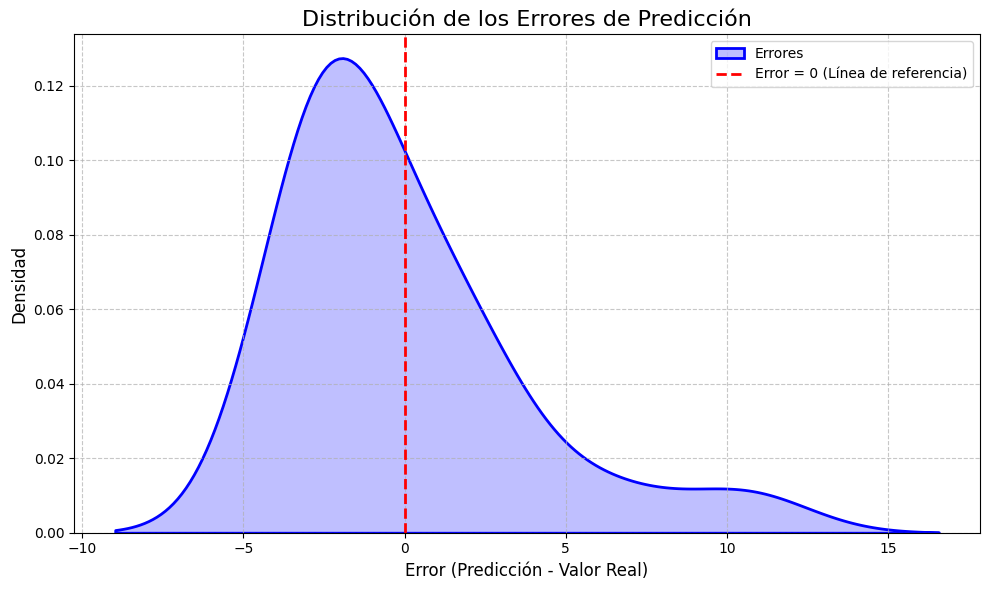

In [319]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calcular los errores (diferencia entre las predicciones y los valores reales)
errores = y_pred - y_test

# Configuración del gráfico
plt.figure(figsize=(10, 6))

# Mejorar el gráfico con kdeplot
sns.kdeplot(errores, fill=True, color='blue', linewidth=2)

# Añadir una línea vertical en cero (para ver la simetría de los errores)
plt.axvline(0, color='red', linestyle='--', linewidth=2)

# Títulos y etiquetas
plt.title('Distribución de los Errores de Predicción', fontsize=16)
plt.xlabel('Error (Predicción - Valor Real)', fontsize=12)
plt.ylabel('Densidad', fontsize=12)

# Mejorar la visibilidad de los ejes y agregar leyenda
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(['Errores', 'Error = 0 (Línea de referencia)'], loc='upper right')

# Mostrar el gráfico
plt.tight_layout()
plt.show()

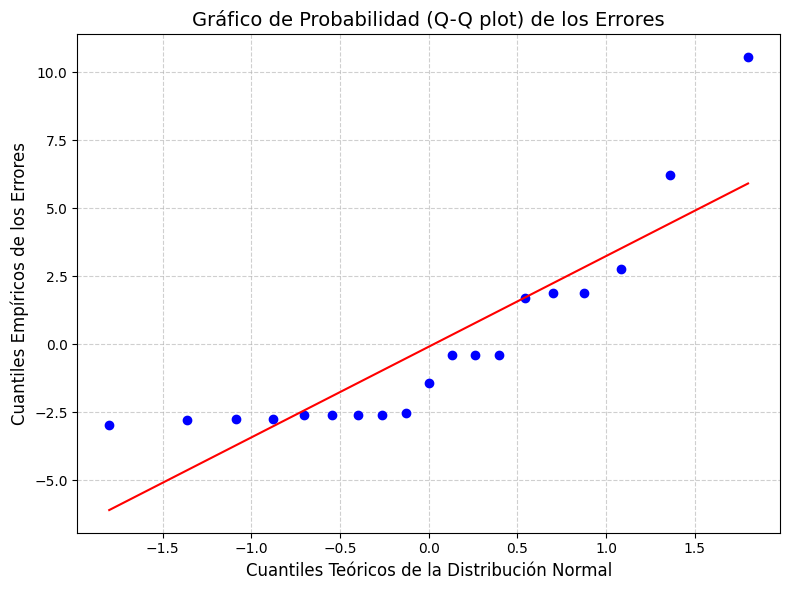

In [320]:
import matplotlib.pyplot as plt
import scipy.stats as stats

# Calcular los errores
errores = y_pred - y_test

# Establecer el tamaño del gráfico
plt.figure(figsize=(8, 6))

# Generar Q-Q plot
stats.probplot(errores, dist="norm", plot=plt)

# Mejorar las etiquetas
plt.title('Gráfico de Probabilidad (Q-Q plot) de los Errores', fontsize=14)
plt.xlabel('Cuantiles Teóricos de la Distribución Normal', fontsize=12)
plt.ylabel('Cuantiles Empíricos de los Errores', fontsize=12)

# Personalizar las líneas
plt.grid(True, linestyle='--', alpha=0.6)  # Añadir una cuadrícula de líneas punteadas

# Mejorar el estilo
plt.gca().get_lines()[0].set_color('blue')  # Cambiar el color de la línea
plt.gca().get_lines()[0].set_linewidth(2)  # Hacer la línea más gruesa

# Mostrar el gráfico
plt.tight_layout()  # Ajustar los márgenes para que no se superpongan los textos
plt.show()

- El siguiente código crea un DataFrame para comparar las predicciones del modelo con los valores reales de consumo. 
- Se genera una tabla con tres columnas: los datos reales (y_test), las predicciones (y_pred) y la diferencia entre ambos. 
- Esta comparación permite analizar el desempeño del modelo de forma visual y cuantitativa.

In [73]:
predicciones_escaleras = df 
predicciones_escaleras = pd.DataFrame({'Datos Reales': y_test, 'Predicciones': y_pred, 'Dif': y_test-y_pred})
print('Comparativo Predicciones Consumo Escaleras Mecanicas Vs Datos Reales')
print(predicciones_escaleras)

Comparativo Predicciones Consumo Escaleras Mecanicas Vs Datos Reales
    Datos Reales  Predicciones        Dif
37          48.4     48.011906   0.388094
27          25.3     22.765469   2.534531
51          24.2     22.765469   1.434531
69          50.6     48.011906   2.588094
0           41.8     48.011906  -6.211906
21         126.5    123.751219   2.748781
38          48.4     48.011906   0.388094
72          50.6     48.011906   2.588094
4           20.9     22.765469  -1.865469
39          96.8     98.504781  -1.704781
88         151.8    148.997656   2.802344
43          48.4     48.011906   0.388094
91         227.7    224.736969   2.963031
74          50.6     48.011906   2.588094
2           20.9     22.765469  -1.865469
10          62.7     73.258344 -10.558344
31         126.5    123.751219   2.748781
19          50.6     48.011906   2.588094
58         121.0    123.751219  -2.751219


# MODELO: "LinearRegression" Ascensores

- El siguiente código realiza una regresión lineal para predecir el consumo eléctrico de los Ascensores. 
- Primero, divide los datos en conjuntos de entrenamiento (80%) y prueba (20%).
-  Luego, entrena un modelo de regresión lineal (LinearRegression) utilizando como variable independiente el número de Ascensores y como dependiente el consumo en kWh. 
- Finalmente, ajusta el modelo con los datos de entrenamiento.

In [321]:
X_train, X_test, y_train, y_test = train_test_split(df[['ascensores']], df['consumo_ascensores_kwh'], test_size=0.2, random_state=42)
print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)

modelesc = linear_model.LinearRegression()
modelesc.fit(X_train, y_train)



(74, 1) (19, 1) (74,) (19,)


LinearRegression()

- El siguiente utiliza el modelo de regresión previamente entrenado para predecir el consumo de energía de los Ascensores. 
- Se aplican los datos de prueba (X_test) como entrada y se obtienen las predicciones (y_pred) correspondientes.

In [322]:
# Predecir consumo de energía
y_pred2 = modelesc.predict(X_test)

**Metricas de Rendimiento**

In [325]:
reg_score=r2_score(y_test,y_pred2)
print(reg_score)
print('R2 (Coeficiente de Determinacion):', reg_score)

mse=mean_squared_error(y_test,y_pred2)
print(mse)
print('MSE (Error Cuadratico Medio):', mse)

rmse=mse**0.5
print(rmse * 100)
print('RMSE (Raiz Cuadrada del Error Cuadratico Medio):', rmse)



0.9962405326159609
R2 (Coeficiente de Determinacion): 0.9962405326159609
79.34720405312174
MSE (Error Cuadratico Medio): 79.34720405312174
890.7704757855513
RMSE (Raiz Cuadrada del Error Cuadratico Medio): 8.907704757855512


**VISALIZACION GRAFICA DE LOS RESUTADOS**

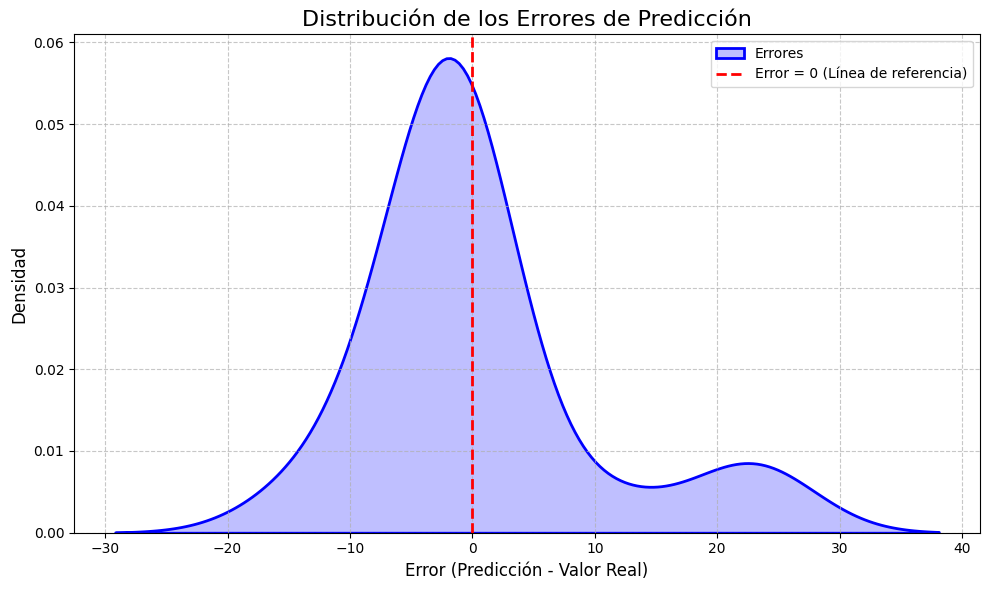

In [327]:
# Calcular los errores (diferencia entre las predicciones y los valores reales)
errores = y_pred2 - y_test

# Configuración del gráfico
plt.figure(figsize=(10, 6))

# Mejorar el gráfico con kdeplot
sns.kdeplot(errores, fill=True, color='blue', linewidth=2)

# Añadir una línea vertical en cero (para ver la simetría de los errores)
plt.axvline(0, color='red', linestyle='--', linewidth=2)

# Títulos y etiquetas
plt.title('Distribución de los Errores de Predicción', fontsize=16)
plt.xlabel('Error (Predicción - Valor Real)', fontsize=12)
plt.ylabel('Densidad', fontsize=12)

# Mejorar la visibilidad de los ejes y agregar leyenda
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(['Errores', 'Error = 0 (Línea de referencia)'], loc='upper right')

# Mostrar el gráfico
plt.tight_layout()
plt.show()

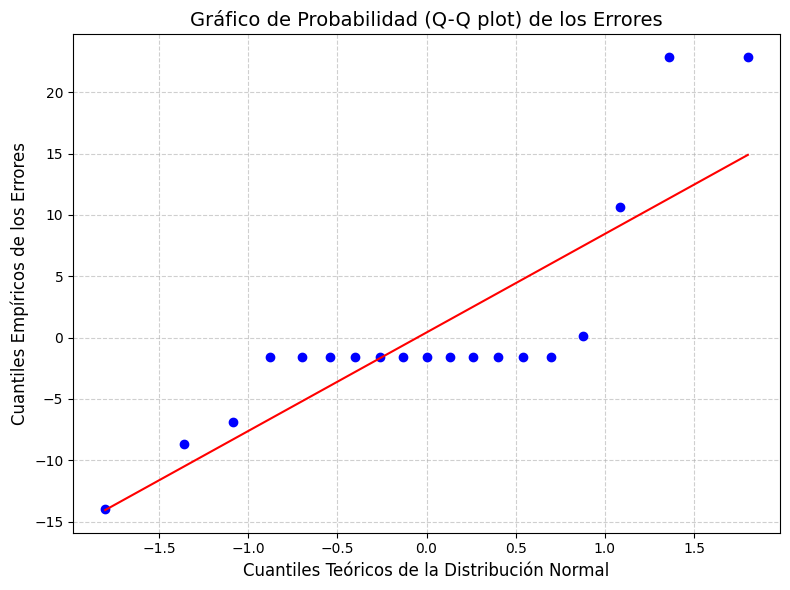

In [328]:
import matplotlib.pyplot as plt
import scipy.stats as stats

# Calcular los errores
errores = y_pred2 - y_test

# Establecer el tamaño del gráfico
plt.figure(figsize=(8, 6))

# Generar Q-Q plot
stats.probplot(errores, dist="norm", plot=plt)

# Mejorar las etiquetas
plt.title('Gráfico de Probabilidad (Q-Q plot) de los Errores', fontsize=14)
plt.xlabel('Cuantiles Teóricos de la Distribución Normal', fontsize=12)
plt.ylabel('Cuantiles Empíricos de los Errores', fontsize=12)

# Personalizar las líneas
plt.grid(True, linestyle='--', alpha=0.6)  # Añadir una cuadrícula de líneas punteadas

# Mejorar el estilo
plt.gca().get_lines()[0].set_color('blue')  # Cambiar el color de la línea
plt.gca().get_lines()[0].set_linewidth(2)  # Hacer la línea más gruesa

# Mostrar el gráfico
plt.tight_layout()  # Ajustar los márgenes para que no se superpongan los textos
plt.show()

In [330]:
predicciones_ascensores = df
predicciones_ascensores = pd.DataFrame({'Datos Reales': y_test, 'Predicciones': y_pred2, 'Dif': y_test-y_pred2})
print('Comparativo Predicciones Consumo Ascensores Vs Datos Reales')
print(predicciones_ascensores)

Comparativo Predicciones Consumo Ascensores Vs Datos Reales
    Datos Reales  Predicciones      Dif
37           0.0       -1.5863   1.5863
27           0.0       -1.5863   1.5863
51          77.0       77.1469  -0.1469
69           0.0       -1.5863   1.5863
0          133.0      155.8801 -22.8801
21         241.5      234.6132   6.8868
38           0.0       -1.5863   1.5863
72           0.0       -1.5863   1.5863
4            0.0       -1.5863   1.5863
39           0.0       -1.5863   1.5863
88         322.0      313.3464   8.6536
43           0.0       -1.5863   1.5863
91         563.5      549.5459  13.9541
74           0.0       -1.5863   1.5863
2           66.5       77.1469 -10.6469
10         133.0      155.8801 -22.8801
31           0.0       -1.5863   1.5863
19           0.0       -1.5863   1.5863
58           0.0       -1.5863   1.5863


# MODELO: "Ridge"

In [331]:
from sklearn.preprocessing import LabelEncoder

In [332]:
#Creo un nuevo dataframe para el modelo de prediccion
df3=df

In [333]:
#Visualizo el nuevo dataframe "df3"
df3.head(10)

,long,lat,linea,estacion,escaleras_mecanicas,ascensores,longitud_km,horas_diarias,consumo_ascensores_kwh,consumo_escaleras_mecanicas_kwh
0,-58.4364,-34.6183,A,ACOYTE,2,2,11.4874,19,133.0,41.8
14,-58.4696,-34.6307,A,SAN PEDRITO,3,2,11.4874,19,133.0,62.7
13,-58.4635,-34.6291,A,SAN JOSE DE FLORES,4,3,11.4874,19,199.5,83.6
12,-58.3868,-34.6094,A,SAENZ PEÑA,2,0,11.4874,19,0.0,41.8
10,-58.4412,-34.6204,A,PRIMERA JUNTA,3,2,11.4874,19,133.0,62.7
9,-58.4067,-34.6098,A,PLAZA MISERERE,6,0,11.4874,19,0.0,125.4
8,-58.3710,-34.6088,A,PLAZA DE MAYO,0,1,11.4874,19,66.5,0.0
11,-58.4486,-34.6235,A,PUAN,3,3,11.4874,19,199.5,62.7
6,-58.3743,-34.6086,A,PERU,2,2,11.4874,19,133.0,41.8
5,-58.4152,-34.6108,A,LORIA,1,1,11.4874,19,66.5,20.9


- El siguientre código convierte las variables categóricas estacion y linea en valores numéricos utilizando codificación con pd.Categorical().codes.
-  Se crean nuevas columnas (ESTACION_NUMERICA y LINEA_NUMERICA) que contienen estas codificaciones, y además se sobrescriben las columnas originales con los mismos valores numéricos.
- Esto facilita su uso en modelos de aprendizaje automático que no aceptan variables categóricas directamente.

In [334]:
df3['ESTACION_NUMERICA']=pd.Categorical(df3['estacion']).codes
df3['estacion']= pd.Categorical(df3['estacion']).codes



df3['LINEA_NUMERICA']=pd.Categorical(df3['linea']).codes
df3['linea']= pd.Categorical(df3['linea']).codes

#target='linea'

#df3 = df3.dropna(subset=[target])
#df3[target] = pd.to_numeric(df3[target],errors='coerce')

#le = LabelEncoder()
#df3[target] = le.fit_transform(df3[target])

#df3=df3[['linea', 'estacion', 'escaleras_mecanicas', 'ascensores','consumo_asc_kwh','consumo_esc_kwh']]
#x2=df3[['estacion', 'escaleras_mecanicas', 'ascensores','consumo_asc_kwh','consumo_esc_kwh']]
#y2=df3[target]

## A continuacion vamos a evaluar distintos modelos de prediccion, para el Consumo electrico de las escaleras.

**Cabe destacar que los modelos sirven para cualquier otra Variable que se desea predecir.**

**Simplemente se hace cambiando el "Target/Objetivo" con el nombre de cualquier otra variable.**

- El siguiente código define el objetivo de predicción (target) como el consumo eléctrico de escaleras mecánicas. 
- Luego, se selecciona un subconjunto del DataFrame original con variables relevantes y se almacenan en dfridge.
- Las variables independientes se asignan a x2 (sin incluir el objetivo), mientras que la variable dependiente se asigna a y2, preparándolos para entrenar un modelo predictivo.

In [335]:

target='consumo_escaleras_mecanicas_kwh'


dfridge=df3[['linea', 'estacion', 'escaleras_mecanicas', 'ascensores','consumo_ascensores_kwh','consumo_escaleras_mecanicas_kwh']]
x2=dfridge[['linea', 'estacion', 'escaleras_mecanicas', 'ascensores','consumo_ascensores_kwh']]
y2=dfridge[target]

**Aprovecho este DATAFRAME y lo voy a utilizar tambien para evaluar otros modelos de prediccion mas abajo.**

In [336]:
dfridge.head(10)

,linea,estacion,escaleras_mecanicas,ascensores,consumo_ascensores_kwh,consumo_escaleras_mecanicas_kwh
0,0,1,2,2,133.0,41.8
14,0,73,3,2,133.0,62.7
13,0,70,4,3,199.5,83.6
12,0,68,2,0,0.0,41.8
10,0,64,3,2,133.0,62.7
9,0,63,6,0,0.0,125.4
8,0,61,0,1,66.5,0.0
11,0,65,3,3,199.5,62.7
6,0,58,2,2,133.0,41.8
5,0,47,1,1,66.5,20.9


- El siguiente código divide los datos en conjuntos de entrenamiento y prueba (80/20) para entrenar y evaluar el modelo.
- Luego, aplica normalización estándar usando StandardScaler, que ajusta los datos para que tengan media 0 y desviación estándar 1.
- Esto mejora el rendimiento y la estabilidad de muchos algoritmos de aprendizaje automático al eliminar escalas dispares entre las variables.

In [337]:
#ESTOS DATOS SE VAN A UTILIZAR PARA ENTRENAR LOS FUTUROS MODELOS.

X_train,X_test,y_train,y_test=train_test_split(x2,y2,test_size=0.2,random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

- Este código aplica selección de características con SelectKBest, eligiendo las variables más relevantes (k=4 en este caso) según su relación estadística con la variable objetivo (y_train). 
- Se ajusta el selector con los datos de entrenamiento escalados y se transforman tanto los datos de entrenamiento como los de prueba, reduciendo así la dimensionalidad y potenciando la eficiencia del modelo.

In [338]:
selectk = 4

selector = SelectKBest(k= selectk)
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)

/Users/claudiocastaneda/Downloads/PROYECTO SUBTE/venv_subte/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw


- El siguiente código imprime un array booleano que indica qué variables fueron seleccionadas por SelectKBest.
-  Cada posición del array corresponde a una columna de las variables originales: True si fue seleccionada entre las mejores k, False si no.
- Esto permite identificar qué características fueron consideradas más relevantes para el modelo.

In [339]:
print(selector.get_support())

[ True False  True  True  True]


- El siguiente código extrae los nombres de las características seleccionadas por SelectKBest.
- Utiliza el array booleano (get_support()) para filtrar las columnas originales de X_train, almacenando los nombres en caracteristicas_selec.
- Finalmente, imprime las variables más relevantes para el modelo según la evaluación estadística realizada.

In [340]:
caracteristicas = selector.get_support()
caracteristicas_selec = X_train.columns[caracteristicas]
print(' Features Seleccionadas por KBest')
print(caracteristicas_selec)

 Features Seleccionadas por KBest
Index(['linea', 'escaleras_mecanicas', 'ascensores', 'consumo_ascensores_kwh'], dtype='object')


- El siguientr código crea una instancia del modelo de regresión Ridge, una variante de la regresión lineal que incluye regularización L2 para reducir el sobreajuste.
- El parámetro alpha=0.1 controla la intensidad de la regularización: cuanto mayor sea el valor, más se penalizan los coeficientes grandes, mejorando la generalización del modelo.

In [341]:
ridge = Ridge(alpha=0.1)

- El siguiente código entrena el modelo de regresión Ridge utilizando las variables seleccionadas (X_train_selected) y los valores reales de consumo (y_train).

In [342]:
ridge.fit(X_train_selected, y_train)

Ridge(alpha=0.1)

**Visualizacion del Rendimiento**

In [343]:
scores = cross_val_score(ridge,X_train_selected, y_train, cv=5)
print(' R2 cercano a 1 = Exitoso ( El modelo SI explica gran proporcion de la Varianza)')
print(' R2 cercano a 0 = No Exitoso( El modelo NO explica gran parte de la Varianza)')
print('       ')
print('Precision del modelo:', scores.mean())


 R2 cercano a 1 = Exitoso ( El modelo SI explica gran proporcion de la Varianza)
 R2 cercano a 0 = No Exitoso( El modelo NO explica gran parte de la Varianza)
       
Precision del modelo: 0.9951248013535485


- El siguiente código genera predicciones con el modelo Ridge previamente entrenado, aplicándolo a los datos de prueba transformados (X_test_selected).
- El resultado (y_predridge) representa los valores estimados de consumo de energía para las escaleras mecánicas.

In [344]:
y_predridge = ridge.predict(X_test_selected)

- Resultados obtenidos

In [345]:
reg_score=r2_score(y_test,y_predridge)
print(reg_score)
print('R2 (Coeficiente de Determinacion):', reg_score)

mse=mean_squared_error(y_test,y_predridge)
print(mse)
print('MSE (Error Cuadratico Medio):', mse)

rmse=mse**0.5
print(rmse * 100)
print('RMSE (Raiz Cuadrada del Error Cuadratico Medio):', rmse)



0.9984108275281495
R2 (Coeficiente de Determinacion): 0.9984108275281495
4.493318867931895
MSE (Error Cuadratico Medio): 4.493318867931895
211.9745000685671
RMSE (Raiz Cuadrada del Error Cuadratico Medio): 2.119745000685671


In [346]:
print(X_train_selected.shape,X_test_selected.shape,y_train.shape,y_test.shape)

(74, 4) (19, 4) (74,) (19,)


**GRAFICOS DE VISALIZACION DE RESUTADOS**

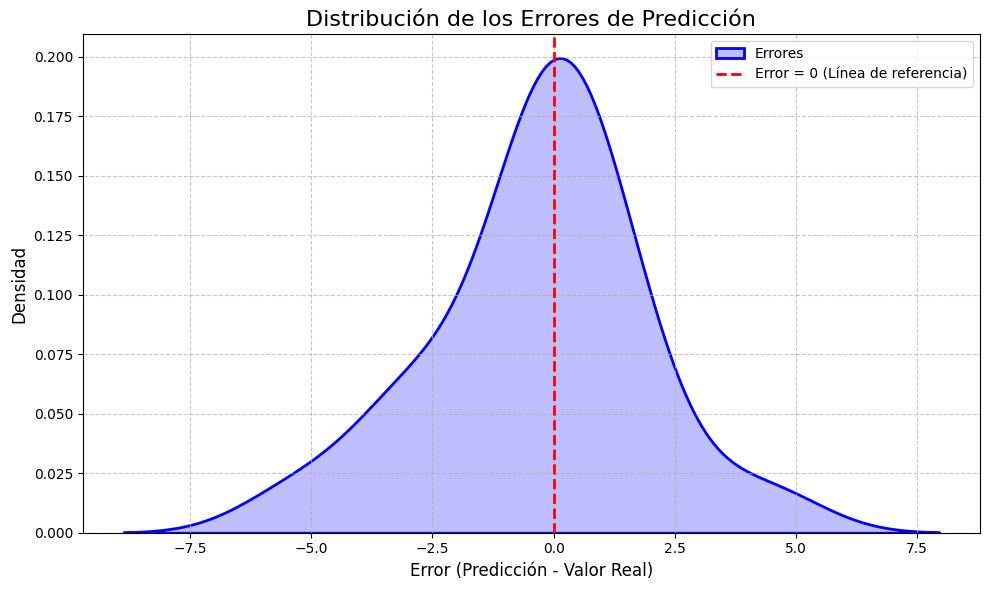

In [350]:
# Calcular los errores (diferencia entre las predicciones y los valores reales)
errores = y_predridge - y_test

# Configuración del gráfico
plt.figure(figsize=(10, 6))

# Mejorar el gráfico con kdeplot
sns.kdeplot(errores, fill=True, color='blue', linewidth=2)

# Añadir una línea vertical en cero (para ver la simetría de los errores)
plt.axvline(0, color='red', linestyle='--', linewidth=2)

# Títulos y etiquetas
plt.title('Distribución de los Errores de Predicción', fontsize=16)
plt.xlabel('Error (Predicción - Valor Real)', fontsize=12)
plt.ylabel('Densidad', fontsize=12)

# Mejorar la visibilidad de los ejes y agregar leyenda
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(['Errores', 'Error = 0 (Línea de referencia)'], loc='upper right')

# Mostrar el gráfico
plt.tight_layout()
plt.show()



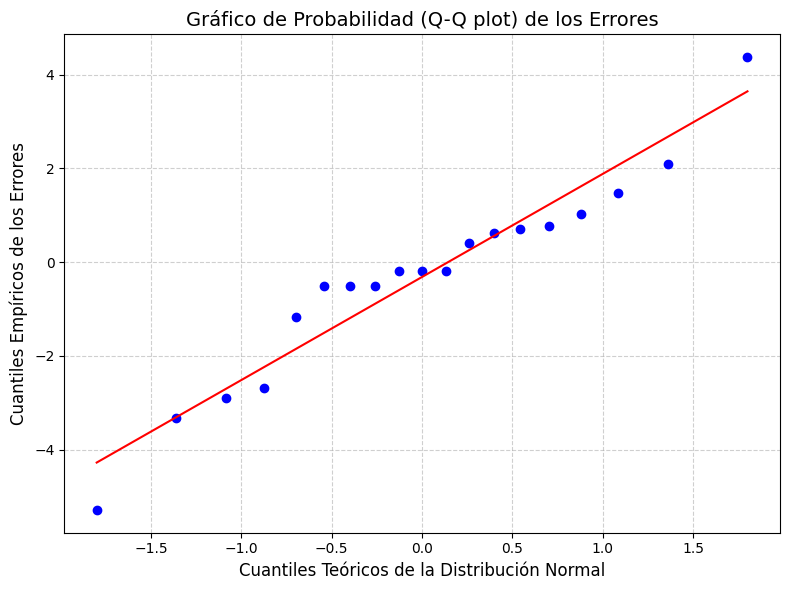

In [351]:

import matplotlib.pyplot as plt
import scipy.stats as stats

# Calcular los errores
errores = y_predridge - y_test

# Establecer el tamaño del gráfico
plt.figure(figsize=(8, 6))

# Generar Q-Q plot
stats.probplot(errores, dist="norm", plot=plt)

# Mejorar las etiquetas
plt.title('Gráfico de Probabilidad (Q-Q plot) de los Errores', fontsize=14)
plt.xlabel('Cuantiles Teóricos de la Distribución Normal', fontsize=12)
plt.ylabel('Cuantiles Empíricos de los Errores', fontsize=12)

# Personalizar las líneas
plt.grid(True, linestyle='--', alpha=0.6)  # Añadir una cuadrícula de líneas punteadas

# Mejorar el estilo
plt.gca().get_lines()[0].set_color('blue')  # Cambiar el color de la línea
plt.gca().get_lines()[0].set_linewidth(2)  # Hacer la línea más gruesa

# Mostrar el gráfico
plt.tight_layout()  # Ajustar los márgenes para que no se superpongan los textos
plt.show()

In [352]:
#VISUALIZO ALGUNAS DE LAS PREDICCIONES VS LOS DATOS REALES
predicciones_escaleras = dfridge
predicciones_escaleras = pd.DataFrame({'Datos Reales': y_test, 'Predicciones': y_predridge, 'Dif': y_test-y_predridge})
print('Comparativo Predicciones Consumo Escaleras Mecanicas Vs. Datos Reales')
print(predicciones_escaleras)

Comparativo Predicciones Consumo Escaleras Mecanicas Vs. Datos Reales
    Datos Reales  Predicciones     Dif
37          48.4       48.2037  0.1963
27          25.3       22.6137  2.6863
51          24.2       24.6098 -0.4098
69          50.6       50.0865  0.5135
0           41.8       42.4264 -0.6264
21         126.5      123.6084  2.8916
38          48.4       48.2037  0.1963
72          50.6       50.0865  0.5135
4           20.9       21.6723 -0.7723
39          96.8       97.5009 -0.7009
88         151.8      152.8228 -1.0228
43          48.4       48.2037  0.1963
91         227.7      229.1689 -1.4689
74          50.6       50.0865  0.5135
2           20.9       19.7251  1.1749
10          62.7       67.0750 -4.3750
31         126.5      121.2081  5.2919
19          50.6       47.2623  3.3377
58         121.0      123.0909 -2.0909


**Conclusión del Modelo Ridge**

- El modelo Ridge ha demostrado un excelente desempeño, generando predicciones muy cercanas a los valores reales, lo cual indica una alta capacidad de ajuste.
- No obstante, se recomienda continuar afinando sus hiperparámetros y validando su rendimiento con diferentes métricas y técnicas de validación cruzada, a fin de asegurar su robustez y evitar posibles casos de sobreajuste.

# MODELO: "DecisionTreeRegressor"

In [353]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error

- El siguiente código entrena un modelo de árbol de regresión (DecisionTreeRegressor) con una profundidad máxima de 5 (max_depth=5 para este caso) para evitar el sobreajuste.
- Se ajusta el modelo con los datos escalados de entrenamiento.
- Luego se generan predicciones (y_predsDTR) sobre los datos de prueba también escalados.
- El modelo busca capturar relaciones no lineales entre las variables y la variable objetivo.

In [354]:
#INGRESAR EL NUMERO DE PROFUNDIDAD MAXIMA DEL ARBOL DE DECISION.
maxdepthDTR = 5

tree_mod=DecisionTreeRegressor(max_depth=maxdepthDTR)
tree_mod.fit(X_train_scaled,y_train)

y_predsDTR=tree_mod.predict(X_test_scaled)



**Visualizacion del Rendimiento**

In [355]:
reg_score=r2_score(y_test,y_predsDTR)
print(reg_score)
print('R2 (Coeficiente de Determinacion):', reg_score)


mse=mean_squared_error(y_test,y_predsDTR)
print(mse)
print('MSE (Error Cuadratico Medio):', mse)

rmse=mse**0.5
print(rmse*100)
print('RMSE (Raiz Cuadrada del Error Cuadratico Medio):', rmse)


0.9991865489116275
R2 (Coeficiente de Determinacion): 0.9991865489116275
2.29999901726704
MSE (Error Cuadratico Medio): 2.29999901726704
151.65747648128135
RMSE (Raiz Cuadrada del Error Cuadratico Medio): 1.5165747648128134


**VISALIZACION GRAFICA DE LOS RESUTADOS**

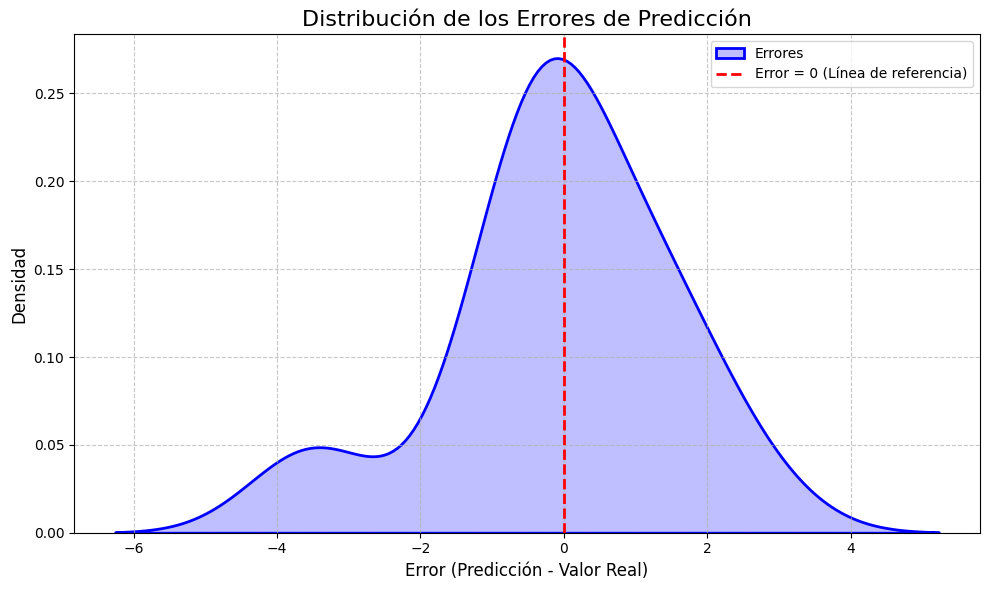

In [356]:
# Calcular los errores (diferencia entre las predicciones y los valores reales)
errores = y_predsDTR - y_test

# Configuración del gráfico
plt.figure(figsize=(10, 6))

# Mejorar el gráfico con kdeplot
sns.kdeplot(errores, fill=True, color='blue', linewidth=2)

# Añadir una línea vertical en cero (para ver la simetría de los errores)
plt.axvline(0, color='red', linestyle='--', linewidth=2)

# Títulos y etiquetas
plt.title('Distribución de los Errores de Predicción', fontsize=16)
plt.xlabel('Error (Predicción - Valor Real)', fontsize=12)
plt.ylabel('Densidad', fontsize=12)

# Mejorar la visibilidad de los ejes y agregar leyenda
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(['Errores', 'Error = 0 (Línea de referencia)'], loc='upper right')

# Mostrar el gráfico
plt.tight_layout()
plt.show()



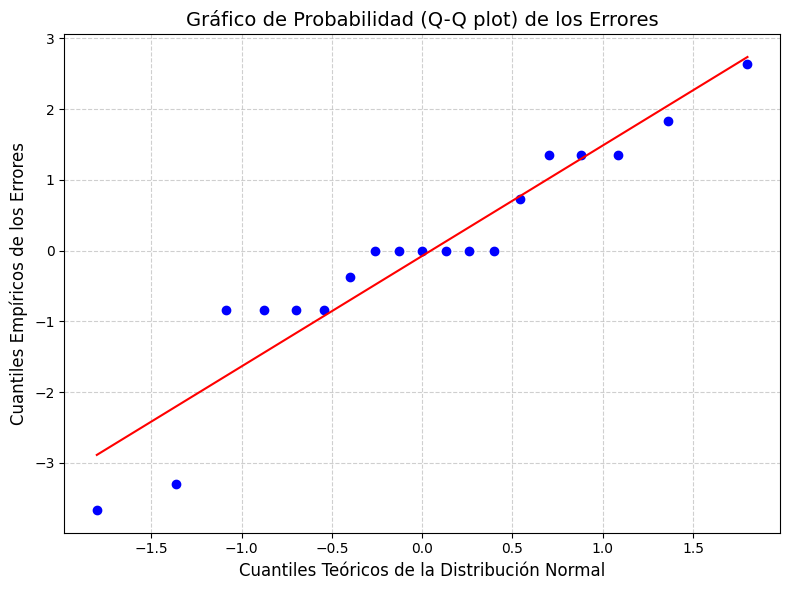

In [357]:

import matplotlib.pyplot as plt
import scipy.stats as stats

# Calcular los errores
errores = y_predsDTR - y_test

# Establecer el tamaño del gráfico
plt.figure(figsize=(8, 6))

# Generar Q-Q plot
stats.probplot(errores, dist="norm", plot=plt)

# Mejorar las etiquetas
plt.title('Gráfico de Probabilidad (Q-Q plot) de los Errores', fontsize=14)
plt.xlabel('Cuantiles Teóricos de la Distribución Normal', fontsize=12)
plt.ylabel('Cuantiles Empíricos de los Errores', fontsize=12)

# Personalizar las líneas
plt.grid(True, linestyle='--', alpha=0.6)  # Añadir una cuadrícula de líneas punteadas

# Mejorar el estilo
plt.gca().get_lines()[0].set_color('blue')  # Cambiar el color de la línea
plt.gca().get_lines()[0].set_linewidth(2)  # Hacer la línea más gruesa

# Mostrar el gráfico
plt.tight_layout()  # Ajustar los márgenes para que no se superpongan los textos
plt.show()

In [361]:
predicciones_escaleras = dfridge
predicciones_escaleras = pd.DataFrame({'Datos Reales': y_test, 'Predicciones': y_predsDTR, 'Dif': y_test-y_predsDTR})
#print('Comparativo Predicciones Consumo Ascensores Vs Datos Reales')
#print(predicciones_escaleras)

pd.set_option('display.width',1000)
pd.set_option('display.precision',4)
print(predicciones_escaleras.head(10))

    Datos Reales  Predicciones     Dif
37          48.4       49.7538 -1.3538
27          25.3       24.9333  0.3667
51          24.2       24.9333 -0.7333
69          50.6       49.7538  0.8462
0           41.8       41.8000  0.0000
21         126.5      126.5000  0.0000
38          48.4       49.7538 -1.3538
72          50.6       49.7538  0.8462
4           20.9       20.9000  0.0000
39          96.8       99.4400 -2.6400


**FINALMENTE, GRAFICO EL ARBOL DE DECISION**

Este código crea una instancia del modelo DecisionTreeRegressor sin parámetros específicos, lo que significa que el árbol crecerá hasta que todas las hojas sean puras o contengan menos de min_samples_split muestras. Esto puede llevar a un sobreajuste si no se controla la profundidad u otros hiperparámetros. Es útil como modelo base o para comparar con versiones regularizadas.

In [105]:
#tree_mod=DecisionTreeRegressor()


- El siguiente código crea una instancia del modelo DecisionTreeRegressor.
- Luego lo entrena con una profundidad máxima definida por maxdepthDTR (por ejemplo, 5).
- Esto controla la complejidad del modelo y mejora su capacidad de generalización.
- Finalmenter, se ajusta el modelo con los datos de entrenamiento escalados y luego se generan nuevas predicciones (y_predsDTR2) sobre el conjunto de prueba.

In [362]:
tree_mod=DecisionTreeRegressor(max_depth=maxdepthDTR)
tree_mod.fit(X_train_scaled,y_train)

y_predsDTR2=tree_mod.predict(X_test_scaled)


- Visualizo el arbol creado anteriormente.

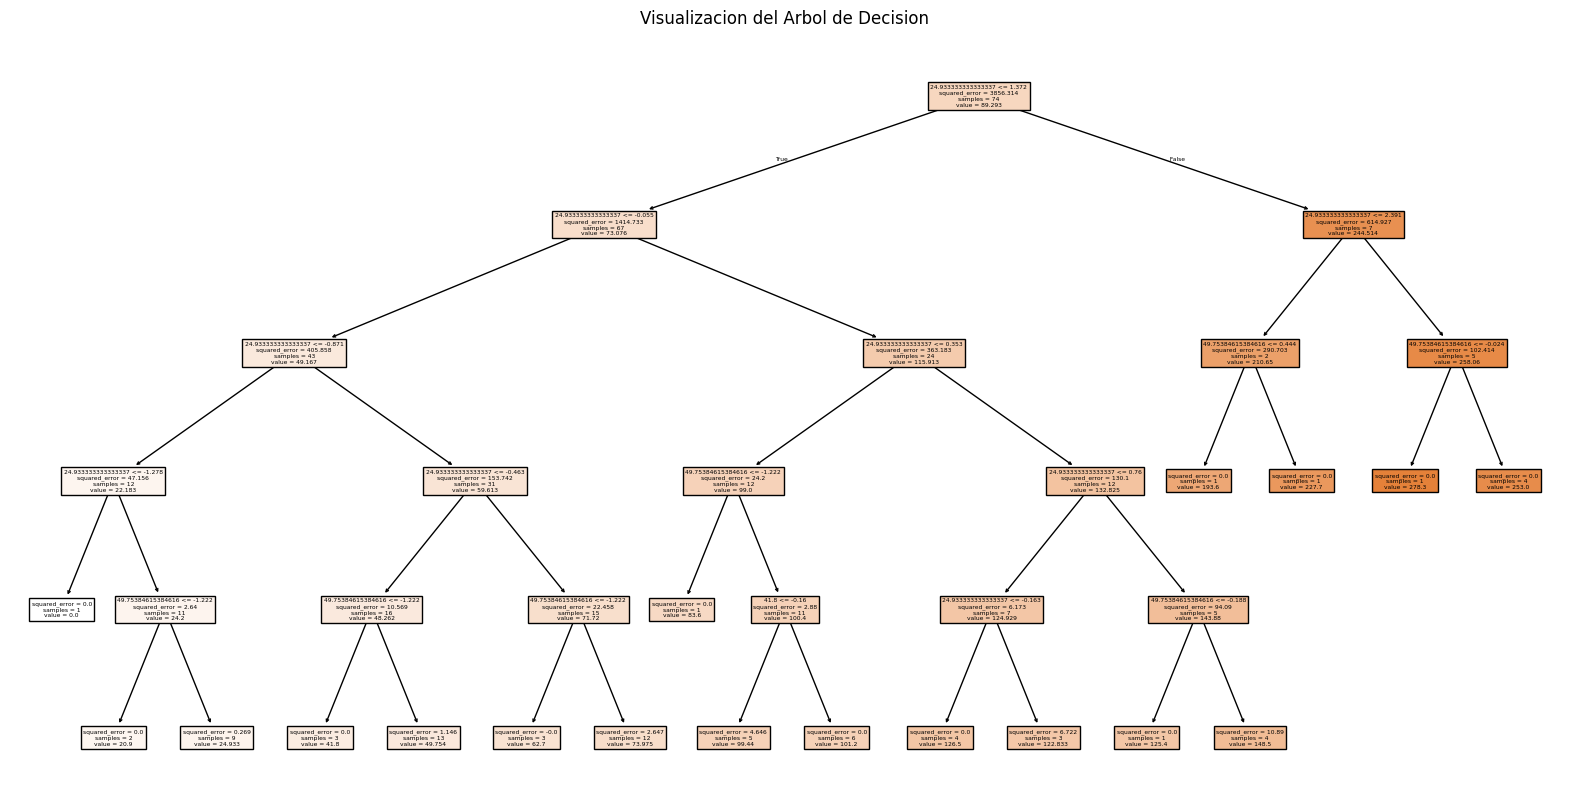

In [363]:
plt.figure(figsize=(20,10))
plot_tree(tree_mod,filled=True,feature_names=y_predsDTR2,class_names=True)
plt.title('Visualizacion del Arbol de Decision')
plt.show()

**Conclusión del Modelo Decision Tree Regressor** 

- El modelo de árbol de regresión, con una profundidad máxima de 5, logro un muy buen nivel de precisión en las predicciones.
- Esta configuración logra un buen equilibrio entre capacidad de ajuste y control del sobreajuste.
- Aun así, es recomendable evaluar su rendimiento con validación cruzada y ajustar hiperparámetros adicionales para optimizar su generalización.

# MODELO: "SVR"

In [364]:
from sklearn.svm import SVR

- El siguiente código define un modelo de Regresión Vectorial de Soporte (SVR) con un kernel lineal y un parámetro de penalización C=1. (Para este caso)
- El parámetro C controla el equilibrio entre minimizar el error y mantener un margen amplio: valores más altos ajustan más a los datos, mientras que valores más bajos priorizan la simplicidad del modelo.
- Esta configuración es adecuada para relaciones lineales entre variables.

In [365]:
#INGRESAR EL VALOR DE C PARA EL MODELO DE REGRESION VECTORIAL.
c = 1

model=SVR(C=c, kernel='linear')

- El siguiente código entrena el modelo SVR con kernel lineal utilizando los datos de entrenamiento (X_train_scaled y y_train).
- Durante el ajuste, el modelo busca encontrar una línea (o hiperplano) que se aproxime a los datos con el menor error posible, permitiendo cierto margen de tolerancia definido por los parámetros del modelo.
- Es útil para capturar relaciones lineales con buena capacidad de generalización.

In [366]:
model.fit(X_train_scaled,y_train)

SVR(C=1, kernel='linear')

- El siguiente código genera predicciones (y_predsSVR) con el modelo SVR entrenado, aplicándolo al conjunto de prueba (X_test). 
- El modelo estima los valores de la variable objetivo (consumo energético en este caso).

In [367]:
y_predsSVR=model.predict(X_test_scaled)

**Visualizacion del Rendimiento**

In [369]:
reg_score=r2_score(y_test,y_predsSVR)
print(reg_score)
print('R2 (Coeficiente de Determinacion):', reg_score)


mse=mean_squared_error(y_test,y_predsSVR)
print(mse)
print('MSE (Error Cuadratico Medio):', mse)

rmse=mse**0.5
print(rmse*100)
print('RMSE (Raiz Cuadrada del Error Cuadratico Medio):', rmse)



0.9663011625596528
R2 (Coeficiente de Determinacion): 0.9663011625596528
95.28205703296432
MSE (Error Cuadratico Medio): 95.28205703296432
976.1252841360289
RMSE (Raiz Cuadrada del Error Cuadratico Medio): 9.761252841360289


**VISALIZACION GRAFICA DE LOS RESUTADOS**

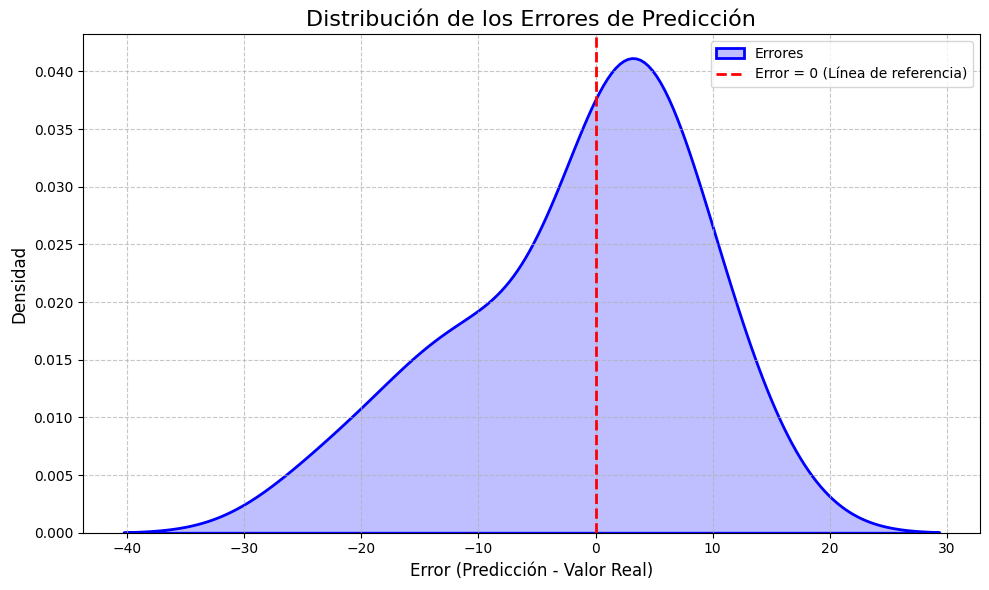

In [373]:
# Calcular los errores (diferencia entre las predicciones y los valores reales)
errores = y_predsSVR - y_test

# Configuración del gráfico
plt.figure(figsize=(10, 6))

# Mejorar el gráfico con kdeplot
sns.kdeplot(errores, fill=True, color='blue', linewidth=2)

# Añadir una línea vertical en cero (para ver la simetría de los errores)
plt.axvline(0, color='red', linestyle='--', linewidth=2)

# Títulos y etiquetas
plt.title('Distribución de los Errores de Predicción', fontsize=16)
plt.xlabel('Error (Predicción - Valor Real)', fontsize=12)
plt.ylabel('Densidad', fontsize=12)

# Mejorar la visibilidad de los ejes y agregar leyenda
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(['Errores', 'Error = 0 (Línea de referencia)'], loc='upper right')

# Mostrar el gráfico
plt.tight_layout()
plt.show()

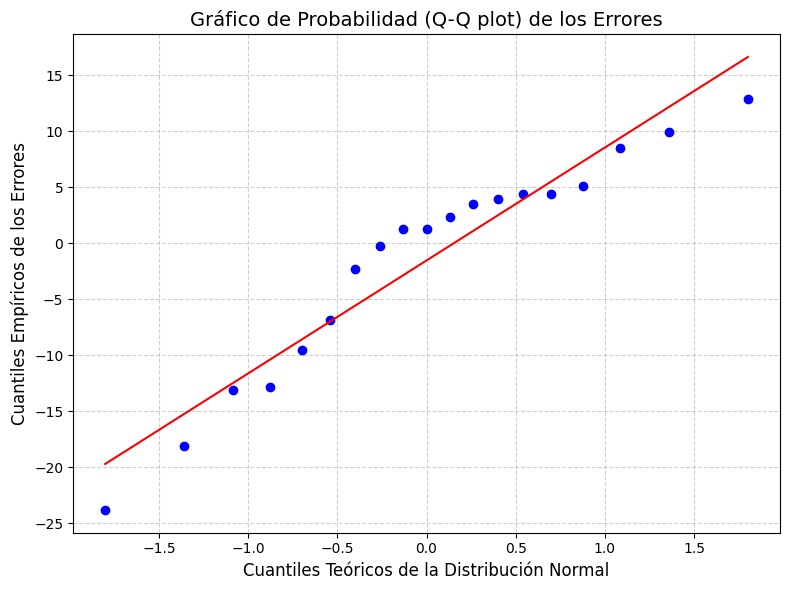

In [374]:
import matplotlib.pyplot as plt
import scipy.stats as stats

# Calcular los errores
errores = y_predsSVR - y_test

# Establecer el tamaño del gráfico
plt.figure(figsize=(8, 6))

# Generar Q-Q plot
stats.probplot(errores, dist="norm", plot=plt)

# Mejorar las etiquetas
plt.title('Gráfico de Probabilidad (Q-Q plot) de los Errores', fontsize=14)
plt.xlabel('Cuantiles Teóricos de la Distribución Normal', fontsize=12)
plt.ylabel('Cuantiles Empíricos de los Errores', fontsize=12)

# Personalizar las líneas
plt.grid(True, linestyle='--', alpha=0.6)  # Añadir una cuadrícula de líneas punteadas

# Mejorar el estilo
plt.gca().get_lines()[0].set_color('blue')  # Cambiar el color de la línea
plt.gca().get_lines()[0].set_linewidth(2)  # Hacer la línea más gruesa

# Mostrar el gráfico
plt.tight_layout()  # Ajustar los márgenes para que no se superpongan los textos
plt.show()

In [375]:
predicciones_escaleras = dfridge
predicciones_escaleras = pd.DataFrame({'Datos Reales': y_test, 'Predicciones': y_predsSVR, 'Dif': y_test-y_predsSVR})
print('Comparativo Predicciones Consumo Escaleras Mecanicas Vs Datos Reales')
print(predicciones_escaleras)

Comparativo Predicciones Consumo Escaleras Mecanicas Vs Datos Reales
    Datos Reales  Predicciones      Dif
37          48.4       49.6648  -1.2648
27          25.3       27.6764  -2.3764
51          24.2       37.0653 -12.8653
69          50.6       55.0236  -4.4236
0           41.8       51.7046  -9.9046
21         126.5      113.6952  12.8048
38          48.4       49.6648  -1.2648
72          50.6       54.5688  -3.9688
4           20.9       25.3154  -4.4154
39          96.8       87.2368   9.5632
88         151.8      144.9816   6.8184
43          48.4       48.1184   0.2816
91         227.7      209.6446  18.0554
74          50.6       54.0684  -3.4684
2           20.9       29.3785  -8.4785
10          62.7       67.7842  -5.0842
31         126.5      102.6839  23.8161
19          50.6       48.2590   2.3410
58         121.0      107.8607  13.1393


**Conclusión del Modelo SVR (Soporte Vectorial para Regresión)**

- El modelo SVR con kernel lineal y parámetro de penalización C=1 logró un alto nivel de precisión.
- Su rendimiento es bueno, aunque ligeramente inferior al de otros modelos más complejos.
- No obstante, es recomendabl explorar con otros valores de C y kernels no lineales para evaluar posibles mejoras en escenarios con relaciones más complejas entre variables.

# MODELO: "RandomForestRegressor"

In [376]:
from sklearn.ensemble import RandomForestRegressor

- El siguiente código entrena un modelo de bosque aleatorio (Random Forest Regressor) con una profundidad máxima de 4 (max_depth=4 para este caso) para controlar su complejidad y evitar sobreajuste.
- El modelo se entrena con los datos de entrenamiento (X_train_scaled, y_train).
- Finalemente, genera predicciones (y_predsRFR) sobre los datos de prueba (X_test_scaled).
- Random Forest mejora la precisión al combinar múltiples árboles de decisión y promediar sus resultados.

In [377]:
#DEFINIR EL NUMERO DE PROFUNDIDAD MAXIMA DEL MODELO DE BOSQUE ALEATORIO.
maxdepthRFR = 4

model=RandomForestRegressor(max_depth=maxdepthRFR)
model.fit(X_train_scaled,y_train)
y_predsRFR=model.predict(X_test_scaled)



**Visualizacion del Rendimiento**

In [378]:
reg_score=r2_score(y_test,y_predsRFR)
print(reg_score)

mse=mean_squared_error(y_test,y_predsRFR)
print(mse)

rmse=mse**0.5
print(rmse*100)

print('R2 (Coeficiente de Determinacion):', reg_score)
print('MSE (Error Cuadratico Medio):', mse)
print('RMSE (Raiz Cuadrada del Error Cuadratico Medio):', rmse)

0.9958231777549028
11.809790651632886
343.6537596423599
R2 (Coeficiente de Determinacion): 0.9958231777549028
MSE (Error Cuadratico Medio): 11.809790651632886
RMSE (Raiz Cuadrada del Error Cuadratico Medio): 3.436537596423599


**VISALIZACION GRAFICA DE LOS RESUTADOS**

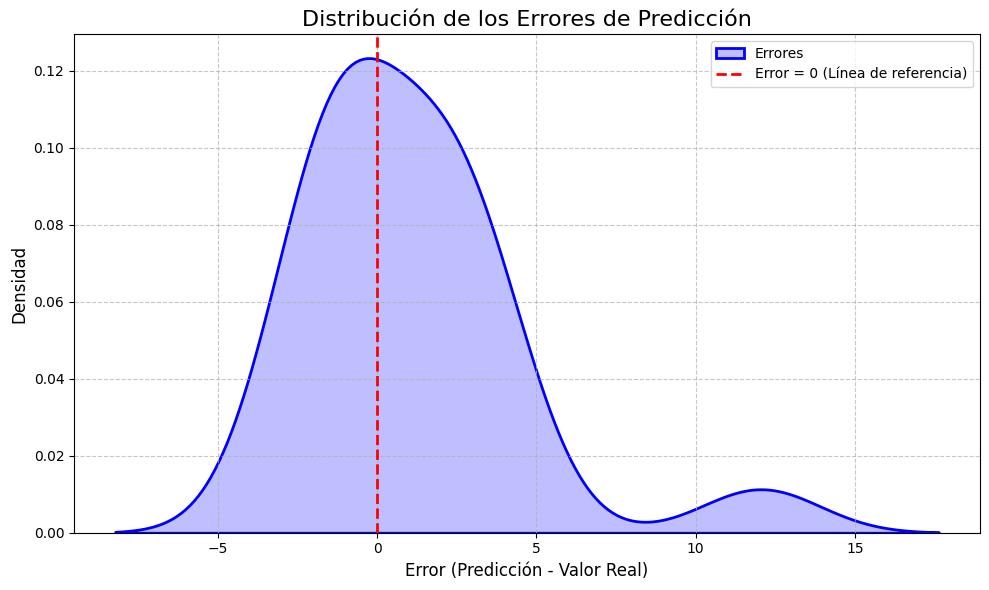

In [381]:
# Calcular los errores (diferencia entre las predicciones y los valores reales)
errores = y_predsRFR - y_test

# Configuración del gráfico
plt.figure(figsize=(10, 6))

# Mejorar el gráfico con kdeplot
sns.kdeplot(errores, fill=True, color='blue', linewidth=2)

# Añadir una línea vertical en cero (para ver la simetría de los errores)
plt.axvline(0, color='red', linestyle='--', linewidth=2)

# Títulos y etiquetas
plt.title('Distribución de los Errores de Predicción', fontsize=16)
plt.xlabel('Error (Predicción - Valor Real)', fontsize=12)
plt.ylabel('Densidad', fontsize=12)

# Mejorar la visibilidad de los ejes y agregar leyenda
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(['Errores', 'Error = 0 (Línea de referencia)'], loc='upper right')

# Mostrar el gráfico
plt.tight_layout()
plt.show()

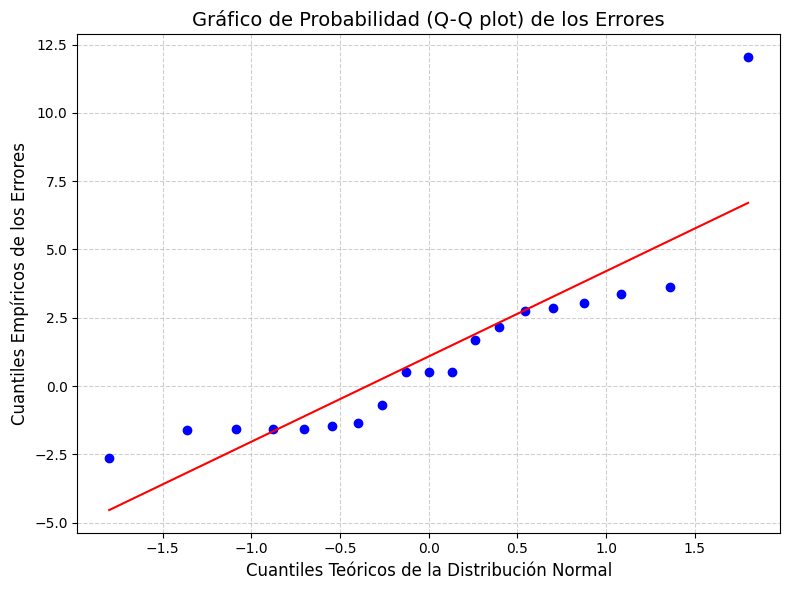

In [382]:
import matplotlib.pyplot as plt
import scipy.stats as stats

# Calcular los errores
errores = y_predsRFR - y_test

# Establecer el tamaño del gráfico
plt.figure(figsize=(8, 6))

# Generar Q-Q plot
stats.probplot(errores, dist="norm", plot=plt)

# Mejorar las etiquetas
plt.title('Gráfico de Probabilidad (Q-Q plot) de los Errores', fontsize=14)
plt.xlabel('Cuantiles Teóricos de la Distribución Normal', fontsize=12)
plt.ylabel('Cuantiles Empíricos de los Errores', fontsize=12)

# Personalizar las líneas
plt.grid(True, linestyle='--', alpha=0.6)  # Añadir una cuadrícula de líneas punteadas

# Mejorar el estilo
plt.gca().get_lines()[0].set_color('blue')  # Cambiar el color de la línea
plt.gca().get_lines()[0].set_linewidth(2)  # Hacer la línea más gruesa

# Mostrar el gráfico
plt.tight_layout()  # Ajustar los márgenes para que no se superpongan los textos
plt.show()

In [383]:
predicciones_escaleras = dfridge
predicciones_escaleras = pd.DataFrame({'Datos Reales': y_test, 'Predicciones': y_predsRFR, 'Dif': y_test-y_predsRFR})
print('Comparativo Predicciones Consumo Escaleras Mecanicas Vs Datos Reales')
print(predicciones_escaleras)

Comparativo Predicciones Consumo Escaleras Mecanicas Vs Datos Reales
    Datos Reales  Predicciones      Dif
37          48.4       48.9014  -0.5014
27          25.3       23.9506   1.3494
51          24.2       23.5011   0.6989
69          50.6       49.0129   1.5871
0           41.8       45.1794  -3.3794
21         126.5      129.2637  -2.7637
38          48.4       48.9014  -0.5014
72          50.6       49.0129   1.5871
4           20.9       23.0493  -2.1493
39          96.8       99.8332  -3.0332
88         151.8      150.3523   1.4477
43          48.4       48.9014  -0.5014
91         227.7      239.7478 -12.0478
74          50.6       49.0129   1.5871
2           20.9       22.5807  -1.6807
10          62.7       65.5698  -2.8698
31         126.5      124.8952   1.6048
19          50.6       47.9635   2.6365
58         121.0      124.6135  -3.6135


**Conclusión del Modelo Random Forest Regressor**

- El modelo Random Forest, configurado con una profundidad máxima de 4, alcanzó un desempeño muy beno en la predicción de los datos. 
- Su capacidad para manejar relaciones no lineales y reducir la varianza a través del ensamblado de múltiples árboles lo convierte en una opción altamente precisa. 
- Aun así, es recomendable seguir evaluando el modelo con validación cruzada para garantizar su estabilidad y evitar sobreajuste.

# MODELO: "XGBRFRegressor"

In [384]:
import xgboost as xgb
from xgboost import XGBRegressor


- El siguiente código configura un modelo XGBoost Random Forest Regressor (XGBRFRegressor) con los siguientes hiperparámetros para este caso:
	•	n_estimators=100: número de árboles del modelo.
	•	learning_rate=0.1: tasa de aprendizaje para ajustar los árboles.
	•	max_depth=3: profundidad máxima de cada árbol.
	•	objective='reg:squarederror': función objetivo para regresión.

- Esta configuración busca un equilibrio entre precisión y generalización al construir múltiples árboles poco profundos que aprenden de los errores anteriores.

In [385]:
#DEFINIR EL NUMERO DE ESTIMADORES, LEARNING RATE Y PROFUNDIDAD MAXIMA DEL MODELO XGBOOST.
estimatorsXGBRFR = 100
learningXGBRFR = 0.1
maxdepthXGRRFR = 3

model_xgbRFR=xgb.XGBRFRegressor(obective='reg:squarederror',n_estimators=estimatorsXGBRFR,learning_rate=learningXGBRFR, max_depth=maxdepthXGRRFR)


- El siguiente código entrena el modelo XGBRFRegressor con los datos de entrenamiento escalados (X_train_scaled y y_train).
- Durante el ajuste, el modelo construye un conjunto de árboles de decisión utilizando la técnica de bosque aleatorio, optimizando la predicción de la variable objetivo mediante múltiples árboles con aprendizaje conjunto y regularización para mejorar la precisión y evitar el sobreajuste.

In [386]:
model_xgbRFR.fit(X_train_scaled,y_train)

/Users/claudiocastaneda/Downloads/PROYECTO SUBTE/venv_subte/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [17:13:44] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "obective" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBRFRegressor(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bytree=None, device=None,
               early_stopping_rounds=None, enable_categorical=False,
               eval_metric=None, feature_types=None, feature_weights=None,
               gamma=None, grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=0.1, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=3, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=100, n_jobs=None,
               num_parallel_tree=None, obective='reg:squarederror', ...)

- El siguiente código genera predicciones (y_predsXGBRFR) utilizando el modelo XGBRFRegressor previamente entrenado, aplicándolo sobre los datos de prueba escalados (X_test_scaled).
- Estas predicciones representan los valores estimados de la variable objetivo.

In [387]:
y_predsXGBRFR=model_xgbRFR.predict(X_test_scaled)

**Analisis de los Resultados**

In [388]:
reg_score=r2_score(y_test,y_predsXGBRFR)
print(reg_score)

mse=mean_squared_error(y_test,y_predsXGBRFR)
print(mse)

rmse=mse**0.5
print(rmse*100)

print('R2 (Coeficiente de Determinacion):', reg_score)
print('MSE (Error Cuadratico Medio):', mse)
print('RMSE (Raiz Cuadrada del Error Cuadratico Medio):', rmse)

0.11902842799579083
2490.9103679530526
4990.902090757795
R2 (Coeficiente de Determinacion): 0.11902842799579083
MSE (Error Cuadratico Medio): 2490.9103679530526
RMSE (Raiz Cuadrada del Error Cuadratico Medio): 49.90902090757795


**VISALIZACION GRAFICA DE LOS RESUTADOS**

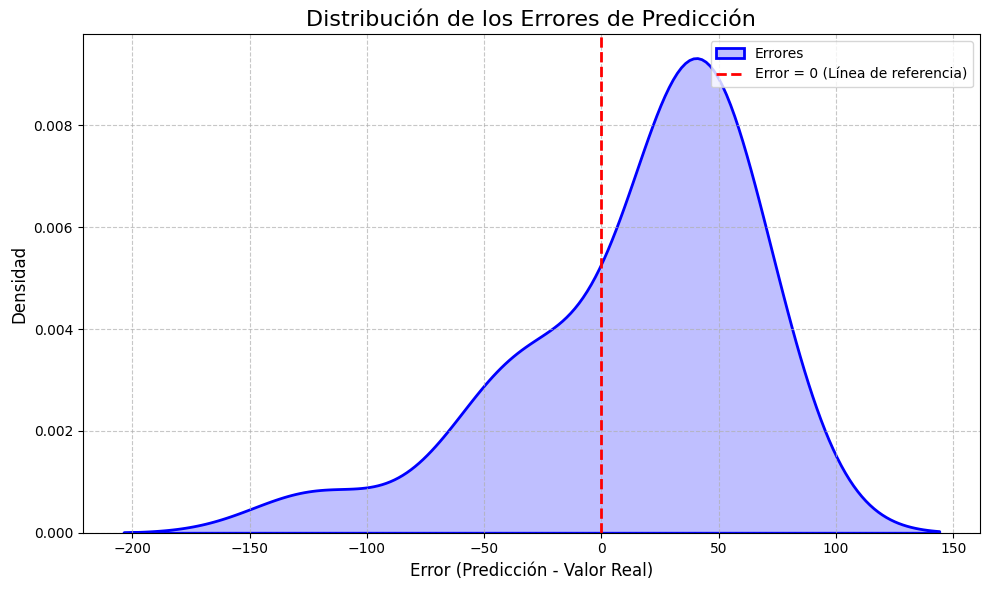

In [394]:
# Calcular los errores (diferencia entre las predicciones y los valores reales)
errores = y_predsXGBRFR - y_test

# Configuración del gráfico
plt.figure(figsize=(10, 6))

# Mejorar el gráfico con kdeplot
sns.kdeplot(errores, fill=True, color='blue', linewidth=2)

# Añadir una línea vertical en cero (para ver la simetría de los errores)
plt.axvline(0, color='red', linestyle='--', linewidth=2)

# Títulos y etiquetas
plt.title('Distribución de los Errores de Predicción', fontsize=16)
plt.xlabel('Error (Predicción - Valor Real)', fontsize=12)
plt.ylabel('Densidad', fontsize=12)

# Mejorar la visibilidad de los ejes y agregar leyenda
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(['Errores', 'Error = 0 (Línea de referencia)'], loc='upper right')

# Mostrar el gráfico
plt.tight_layout()
plt.show()

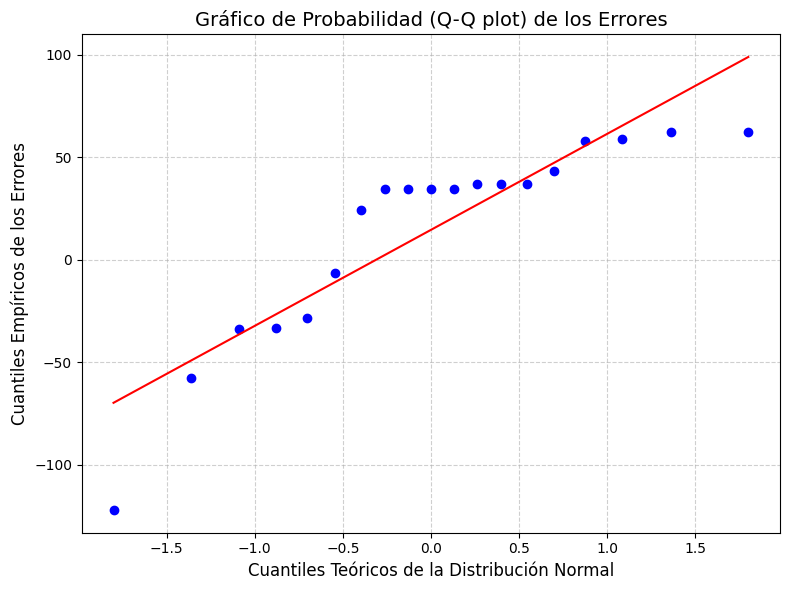

In [395]:
import matplotlib.pyplot as plt
import scipy.stats as stats

# Calcular los errores
errores = y_predsXGBRFR - y_test

# Establecer el tamaño del gráfico
plt.figure(figsize=(8, 6))

# Generar Q-Q plot
stats.probplot(errores, dist="norm", plot=plt)

# Mejorar las etiquetas
plt.title('Gráfico de Probabilidad (Q-Q plot) de los Errores', fontsize=14)
plt.xlabel('Cuantiles Teóricos de la Distribución Normal', fontsize=12)
plt.ylabel('Cuantiles Empíricos de los Errores', fontsize=12)

# Personalizar las líneas
plt.grid(True, linestyle='--', alpha=0.6)  # Añadir una cuadrícula de líneas punteadas

# Mejorar el estilo
plt.gca().get_lines()[0].set_color('blue')  # Cambiar el color de la línea
plt.gca().get_lines()[0].set_linewidth(2)  # Hacer la línea más gruesa

# Mostrar el gráfico
plt.tight_layout()  # Ajustar los márgenes para que no se superpongan los textos
plt.show()

In [396]:
predicciones_escaleras = dfridge
predicciones_escaleras = pd.DataFrame({'Datos Reales': y_test, 'Predicciones': y_predsXGBRFR, 'Dif': y_test-y_predsXGBRFR})
print('Comparativo Predicciones Consumo Escaleras Mecanicas Vs Datos Reales')
print(predicciones_escaleras)

Comparativo Predicciones Consumo Escaleras Mecanicas Vs Datos Reales
    Datos Reales  Predicciones       Dif
37          48.4       85.2830  -36.8830
27          25.3       83.2989  -57.9989
51          24.2       83.2938  -59.0938
69          50.6       85.2449  -34.6449
0           41.8       85.0977  -43.2977
21         126.5       93.0344   33.4656
38          48.4       85.2830  -36.8830
72          50.6       85.2830  -34.6830
4           20.9       83.2408  -62.3408
39          96.8       90.2279    6.5721
88         151.8       94.0929   57.7071
43          48.4       85.2830  -36.8830
91         227.7      105.6149  122.0851
74          50.6       85.2830  -34.6830
2           20.9       83.1747  -62.2747
10          62.7       87.1067  -24.4067
31         126.5       92.5818   33.9182
19          50.6       85.1838  -34.5838
58         121.0       92.6312   28.3688


**Conclusión del Modelo XGBRFRegressor**

- A pesar de ser un modelo robusto basado en árboles aleatorios, el XGBRFRegressor, con 100 estimadores, learning_rate=0.1 y max_depth=3, tuvo una muy baja capacidad predictiva bajo esta configuración.
- Este resultado sugiere una posible subajuste del modelo (underfitting), probablemente debido a una combinación de parámetros no óptimos.
- Habria que ajustar hiperparámetros clave —como aumentar la profundidad, modificar la tasa de aprendizaje o el número de estimadores— y verificar la correcta preparación de los datos para mejorar el rendimiento.